# 03. 탐색적 데이터 분석 (EDA) — 황학동 상권의 변화 신호 탐색

## 이 노트북의 목적

`02_preprocessing.ipynb`에서 정리·검증된 `data/processed/sales.csv`, `stores.csv`, `population.csv`를 바탕으로,
황학동 4개 상권(3110055, 3110057, 3130054, 3130055)의 매출·점포·생활인구·소비구조가
2021Q1~2025Q4 동안 시간·업종·소비(시간대/요일/연령)별로 어떻게 변화했는지 체계적으로 탐색한다.

- 이번 단계의 목적은 단순한 현황 설명이 아니라 **이후 쇠퇴·회복 신호를 정의하기 위한 근거가 될 "변화 신호"를 찾는 것**이다.
- 황학동 4개 상권을 주요 분석 대상으로 삼되, `data/processed`에 그대로 유지된 **서울 전체 상권 데이터를 비교 기준**으로 활용한다.
  - 황학동 추세가 서울 전체와 다른 방향인지
  - 특정 변화가 황학동만의 특징인지, 서울 전체에서도 나타나는 공통 현상인지
  - 서울 전체 상권 분포 안에서 황학동이 상대적으로 어디에 위치하는지
  - 이후 유사 상권 탐색·군집분석을 위한 기반을 마련하는 것
- 이 EDA의 결과는 이후 `04` 단계에서 쇠퇴·회복 신호(지표)를 설계하는 근거로 사용되며, **이번 단계에서 최종 쇠퇴/회복 판정이나 정책 제안(Action Plan)을 내리지 않는다.**

## 이번 노트북에서 하지 않는 것

- 상권 쇠퇴지수·회복지수·Commercial Vitality Score 등 종합 점수 산출
- K-means, PCA 등 모델링, 유사 상권 탐색 알고리즘, 이상탐지
- AI/LLM/MCP 연동, Tableau 대시보드 구축
- Action Plan 제안
- "황학동은 쇠퇴했다/회복 중이다"와 같은 단정적 결론, 관찰된 관계의 인과관계 해석
- `data/processed`에 새로운 feature 저장 (이번 단계의 변화율·구성비·index는 EDA용 임시 변수로만 사용)

## 1. 라이브러리 및 경로 설정

`pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`, `pathlib.Path`를 기본으로 사용한다.
이 노트북은 `notebooks/` 폴더에 위치하므로 `data/processed`는 상대경로(`../data/processed`)로 접근한다.

한글 폰트는 특정 PC의 절대 경로를 하드코딩하지 않고, 현재 실행 환경에 실제로 설치된 폰트 목록에서
사용 가능한 한글 폰트를 탐색하여 설정한다. 그래프 스타일(`seaborn` theme, 색상 팔레트)은 노트북 전체에서
일관되게 유지한다.

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROCESSED_DIR = Path("../data/processed")

SALES_PATH = PROCESSED_DIR / "sales.csv"
STORES_PATH = PROCESSED_DIR / "stores.csv"
POPULATION_PATH = PROCESSED_DIR / "population.csv"

for name, p in [("SALES_PATH", SALES_PATH), ("STORES_PATH", STORES_PATH), ("POPULATION_PATH", POPULATION_PATH)]:
    print(f"{name:16s} {p} -> exists: {p.exists()}")

SALES_PATH       ..\data\processed\sales.csv -> exists: True
STORES_PATH      ..\data\processed\stores.csv -> exists: True
POPULATION_PATH  ..\data\processed\population.csv -> exists: True


In [3]:
# 그래프 스타일 및 한글 폰트 설정
# 특정 PC의 절대 폰트 경로를 하드코딩하지 않고, 현재 환경에 설치된 폰트 중에서 탐색한다.
sns.set_theme(style="whitegrid")

_KOREAN_FONT_CANDIDATES = [
    "Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic",
    "Noto Sans CJK KR", "Noto Sans KR", "Gulim",
]
_available_fonts = {f.name for f in fm.fontManager.ttflist}
_font_name = next((c for c in _KOREAN_FONT_CANDIDATES if c in _available_fonts), None)

if _font_name:
    plt.rcParams["font.family"] = _font_name
    print(f"한글 폰트 설정: {_font_name}")
else:
    print("경고: 사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글 라벨이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False
# 로그축 등에서 mathtext로 렌더링되는 지수 표기(예: 10^-1)는 axes.unicode_minus의 영향을 받지 않고
# 별도의 mathtext 폰트셋을 사용하므로, 유니코드 마이너스 글리프를 지원하는 폰트셋으로 지정한다.
plt.rcParams["mathtext.fontset"] = "dejavusans"

# 로그축 눈금의 지수 표기 렌더링 과정에서 발생하는 폰트 글리프 관련 경고(matplotlib 내부 logging)는
# 분석 결과에 영향을 주지 않는 콘솔 메시지이므로, 노트북 가독성을 위해 로그 레벨만 조정한다.
import logging
logging.getLogger("matplotlib").setLevel(logging.ERROR)
plt.rcParams["figure.dpi"] = 100

# 노트북 전체에서 일관되게 사용할 색상
SEOUL_COLOR = "#9E9E9E"       # 서울 전체 비교 기준선(회색)
HWANGHAK_COLOR = "#C0392B"    # 황학동 합계(진한 빨강)
AREA_PALETTE = sns.color_palette("Set2", 4)  # 황학 4개 상권 개별 색상

한글 폰트 설정: Malgun Gothic


## 2. processed 데이터 로드 및 최소 검증

`02_preprocessing.ipynb`에서 이미 결측치·중복·key 정합성 등 품질 검증을 완료했으므로,
여기서는 전체 품질 검사를 반복하지 않고 **데이터가 예상대로 읽혔는지** 정도만 가볍게 재확인한다.
저장 시 `encoding="utf-8-sig"`를 사용했으므로 로드 시에도 동일한 인코딩을 사용한다.

In [4]:
sales = pd.read_csv(SALES_PATH, encoding="utf-8-sig")
stores = pd.read_csv(STORES_PATH, encoding="utf-8-sig")
population = pd.read_csv(POPULATION_PATH, encoding="utf-8-sig")

for label, df in [("sales", sales), ("stores", stores), ("population", population)]:
    print(f"[{label}]")
    print("  shape:", df.shape)
    print("  기간 min/max:", df["기준_년분기_코드"].min(), "~", df["기준_년분기_코드"].max())
    print("  고유 분기 수:", df["기준_년분기_코드"].nunique())
    print("  상권 수:", df["상권_코드"].nunique())
    print("  기준_년분기_코드 dtype:", df["기준_년분기_코드"].dtype, "/ 상권_코드 dtype:", df["상권_코드"].dtype)
    print()

[sales]
  shape: (439141, 55)
  기간 min/max: 20211 ~ 20254
  고유 분기 수: 20
  상권 수: 1596
  기준_년분기_코드 dtype: int64 / 상권_코드 dtype: int64

[stores]
  shape: (1528872, 14)
  기간 min/max: 20211 ~ 20254
  고유 분기 수: 20
  상권 수: 1650
  기준_년분기_코드 dtype: int64 / 상권_코드 dtype: int64

[population]
  shape: (32984, 27)
  기간 min/max: 20211 ~ 20254
  고유 분기 수: 20
  상권 수: 1650
  기준_년분기_코드 dtype: int64 / 상권_코드 dtype: int64



## 3. 분석용 상수 및 기간 라벨 생성

`상권_코드` 실제 dtype(`int64`)에 맞춰 황학 4개 상권코드를 정수 리스트로 정의한다.
`기준_년분기_코드`(예: 20211)를 그래프에서 읽기 쉬운 `2021Q1` 형태로 보여주기 위한 라벨을 별도로 만들되,
원본 key 컬럼은 그대로 두고 EDA용 임시 컬럼(`분기_라벨`)으로만 추가한다. 시간 순서를 보장하기 위해
`분기_라벨`은 실제 등장 순서를 기준으로 한 ordered category로 만든다.

In [5]:
HWANGHAK_CODES = [3110055, 3110057, 3130054, 3130055]
assert pd.api.types.is_integer_dtype(sales["상권_코드"])
print("HWANGHAK_CODES:", HWANGHAK_CODES, "(dtype: 상권_코드와 동일한 정수)")


def to_quarter_label(code):
    """20211 -> '2021Q1' 형태로 변환한다."""
    code = int(code)
    year, q = divmod(code, 10)
    return f"{year}Q{q}"


QUARTER_ORDER = sorted(sales["기준_년분기_코드"].unique().tolist())
QUARTER_LABELS = [to_quarter_label(q) for q in QUARTER_ORDER]
QUARTER_LABEL_MAP = dict(zip(QUARTER_ORDER, QUARTER_LABELS))

print("분기 수:", len(QUARTER_ORDER))
print("분기 라벨 범위:", QUARTER_LABELS[0], "~", QUARTER_LABELS[-1])


def add_quarter_label(df, quarter_col="기준_년분기_코드"):
    """원본 DataFrame을 수정하지 않고, 분기_라벨(ordered category) 컬럼을 추가한 복사본을 반환한다."""
    out = df.copy()
    out["분기_라벨"] = pd.Categorical(
        out[quarter_col].map(QUARTER_LABEL_MAP), categories=QUARTER_LABELS, ordered=True
    )
    return out

HWANGHAK_CODES: [3110055, 3110057, 3130054, 3130055] (dtype: 상권_코드와 동일한 정수)
분기 수: 20
분기 라벨 범위: 2021Q1 ~ 2025Q4


## 4. 황학 4개 상권 기본 확인

`02_preprocessing.ipynb`에서 상권코드-상권명 표기 불일치 사례(예: 3110024 `혜회동주민센터`/`혜화동주민센터`)가
발견되었으므로, 분석의 식별자는 항상 `상권_코드`를 기준으로 하고 `상권_코드_명`은 그래프 라벨 표시용으로만 사용한다.
아래에서는 황학 4개 상권코드 자체에도 이런 표기 불일치가 있는지 확인하고, 20개 분기가 세 데이터 모두에
빠짐없이 존재하는지 재확인한다.

In [6]:
hwanghak_sales = sales[sales["상권_코드"].isin(HWANGHAK_CODES)].copy()
hwanghak_stores = stores[stores["상권_코드"].isin(HWANGHAK_CODES)].copy()
hwanghak_population = population[population["상권_코드"].isin(HWANGHAK_CODES)].copy()

info_rows = []
for label, df in [("sales", hwanghak_sales), ("stores", hwanghak_stores), ("population", hwanghak_population)]:
    for code_ in HWANGHAK_CODES:
        sub = df[df["상권_코드"] == code_]
        names = sorted(sub["상권_코드_명"].unique().tolist())
        info_rows.append({
            "데이터": label,
            "상권_코드": code_,
            "상권_코드_명 표기": names,
            "표기 종류 수": len(names),
            "고유 분기 수": sub["기준_년분기_코드"].nunique(),
        })

hwanghak_info = pd.DataFrame(info_rows)
display(hwanghak_info)

multi_name = hwanghak_info[hwanghak_info["표기 종류 수"] > 1]
if len(multi_name) > 0:
    print("황학 4개 상권 중 상권명 표기가 여러 개인 사례가 있습니다 (아래 참고, 임의 수정하지 않음):")
    display(multi_name)
else:
    print("황학 4개 상권은 세 데이터 모두에서 상권명 표기가 단일하게 유지되고 있음을 확인했습니다.")

assert (hwanghak_info["고유 분기 수"] == 20).all(), "황학 4개 상권 중 20개 분기를 모두 채우지 못한 경우가 있습니다."
print("\n황학 4개 상권 모두 20개 분기(2021Q1~2025Q4) 전체 존재 확인 완료.")

,데이터,상권_코드,상권_코드_명 표기,표기 종류 수,고유 분기 수
0,sales,3110055,[황학동벼룩시장],1,20
1,sales,3110057,[황학코아루아파트],1,20
2,sales,3130054,[황학동주방가구거리상점가],1,20
3,sales,3130055,"[황학시장(서울중앙시장, 신중앙시장)]",1,20
4,stores,3110055,[황학동벼룩시장],1,20
5,stores,3110057,[황학코아루아파트],1,20
6,stores,3130054,[황학동주방가구거리상점가],1,20
7,stores,3130055,"[황학시장(서울중앙시장, 신중앙시장)]",1,20
8,population,3110055,[황학동벼룩시장],1,20
9,population,3110057,[황학코아루아파트],1,20


황학 4개 상권은 세 데이터 모두에서 상권명 표기가 단일하게 유지되고 있음을 확인했습니다.

황학 4개 상권 모두 20개 분기(2021Q1~2025Q4) 전체 존재 확인 완료.


## 5. 서울 전체와 황학동을 비교할 때의 집계 기준 정의

서울 전체 상권 수(약 1,650개)와 황학동 4개 상권을 단순 총합으로 비교하면 규모 차이 때문에 비교 자체가
무의미해진다. 이 노트북에서는 분석 목적에 따라 아래 세 가지 집계 방식을 구분해서 사용하며, 각 그래프
앞에서 어떤 방식을 썼는지 다시 명시한다.

1. **황학 4개 상권 합계 규모 분석** — 황학 4개 상권의 값을 그대로 합계하여 사용한다 (황학동 자체의 절대적인 변화를 볼 때).
2. **상권 간 상대 비교** — 상권별 값(황학 개별 상권 또는 서울 개별 상권)을 먼저 계산한 뒤, 서울 전체 상권의
   median·mean·quartile과 비교한다. 이때 "서울 총합"이 아니라 "상권 1개당 값"의 분포를 사용한다.
3. **시계열 추세 비교** — 절대 규모가 다른 두 그룹(황학동 vs 서울)의 성장/감소 "경로"만 비교하고 싶을 때는
   `2021Q1 = 100` 기준 index로 변환하여 두 지수 곡선의 방향과 기울기를 비교한다. 이 index는 그래프 해석을 위한
   임시 변수이며 `data/processed`에 저장하지 않는다.

즉, **서울 전체 총매출과 황학동 총매출을 같은 그래프에 그대로 겹쳐 그리는 방식은 사용하지 않는다.**

## 6. 매출 전체 추세 분석

### 6-1. 황학동 4개 상권 합계 분기별 매출 추세

**집계 기준: 황학 4개 상권 합계 규모 분석** (황학 4개 상권 `당월_매출_금액`/`당월_매출_건수` 합계).
금액과 건수는 단위와 의미가 다르므로 같은 y축에 억지로 그리지 않고 별도 그래프로 확인한다.

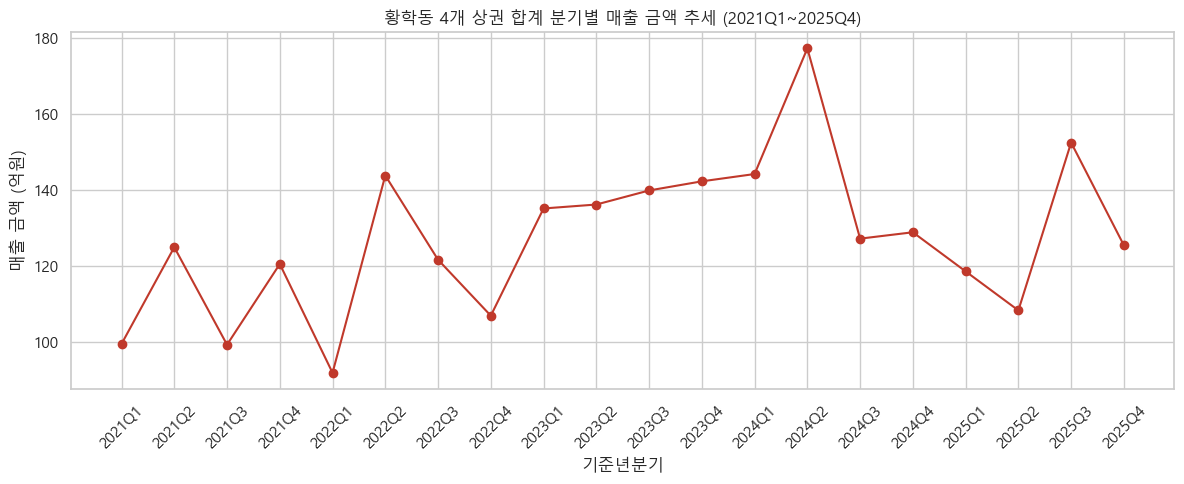

In [7]:
hwanghak_quarterly_sales = hwanghak_sales.groupby("기준_년분기_코드", as_index=False).agg(
    총매출금액=("당월_매출_금액", "sum"),
    총매출건수=("당월_매출_건수", "sum"),
)
hwanghak_quarterly_sales = add_quarter_label(hwanghak_quarterly_sales).sort_values("분기_라벨")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hwanghak_quarterly_sales["분기_라벨"], hwanghak_quarterly_sales["총매출금액"] / 1e8,
        marker="o", color=HWANGHAK_COLOR)
ax.set_title("황학동 4개 상권 합계 분기별 매출 금액 추세 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("매출 금액 (억원)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

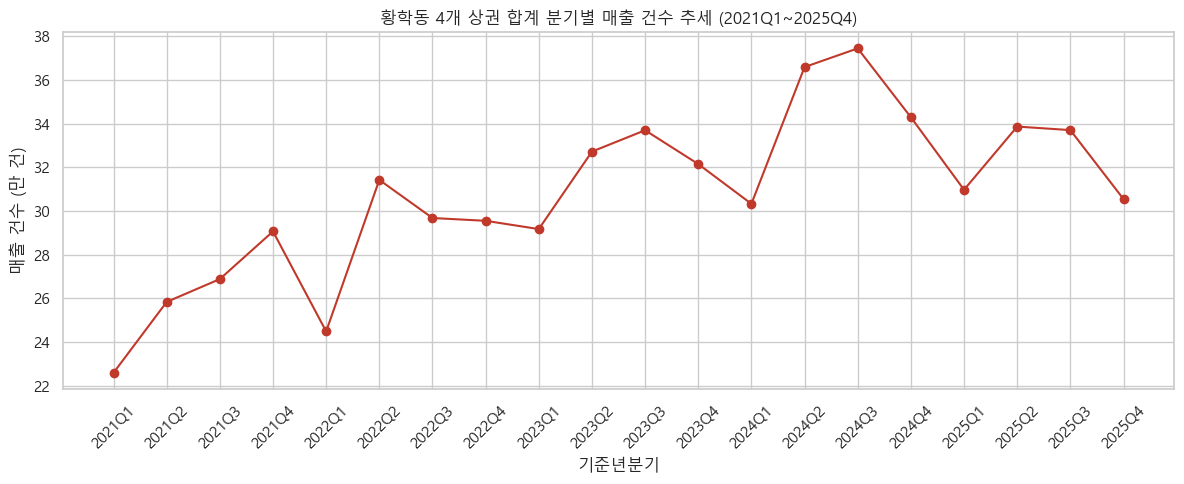

 분기_라벨       총매출금액  총매출건수
2021Q1  9960896474 225882
2021Q2 12503021304 258360
2021Q3  9940621863 268830
2021Q4 12060960355 290672
2022Q1  9202709933 244838
2022Q2 14386475400 314276
2022Q3 12173543979 296803
2022Q4 10703019867 295526
2023Q1 13520777698 291746
2023Q2 13624442337 327235
2023Q3 13993752516 337015
2023Q4 14233801113 321526
2024Q1 14425818155 303305
2024Q2 17727023191 365980
2024Q3 12728022938 374530
2024Q4 12895280470 342981
2025Q1 11868081636 309747
2025Q2 10842514973 338708
2025Q3 15251538955 337088
2025Q4 12552413927 305481


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hwanghak_quarterly_sales["분기_라벨"], hwanghak_quarterly_sales["총매출건수"] / 1e4,
        marker="o", color=HWANGHAK_COLOR)
ax.set_title("황학동 4개 상권 합계 분기별 매출 건수 추세 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("매출 건수 (만 건)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(hwanghak_quarterly_sales[["분기_라벨", "총매출금액", "총매출건수"]].to_string(index=False))

**해석:** 황학동 4개 상권 합계 매출금액은 2021Q1 약 99.6억원에서 2025Q4 약 125.5억원으로 완만하게
늘었지만, 그 사이 분기별 변동폭이 매우 크다(최저 2022Q1 약 92.0억원 ~ 최고 2024Q2 약 177.3억원). 특정
방향으로 단조 감소하는 모습은 아니며, 오히려 등락을 반복하며 완만한 우상향 추세에 가깝다. 매출 건수는
2021Q1 225,882건에서 2025Q4 305,481건으로 약 +35% 늘어 매출금액 증가폭(+26%)보다 크며, 이는 건당
평균 매출(객단가)이 다소 낮아지는 방향과 함께 나타난 변화임을 시사한다(원인은 이후 업종별 분석에서 살펴본다).

### 6-2. 황학 4개 상권별 매출 추세

**집계 기준: 상권 간 개별 비교** (4개 상권 각각의 분기별 매출 금액 합계, 총합이 아님).
한 상권의 변화가 황학동 4개 상권 합계 추세를 주도하는지 확인한다.

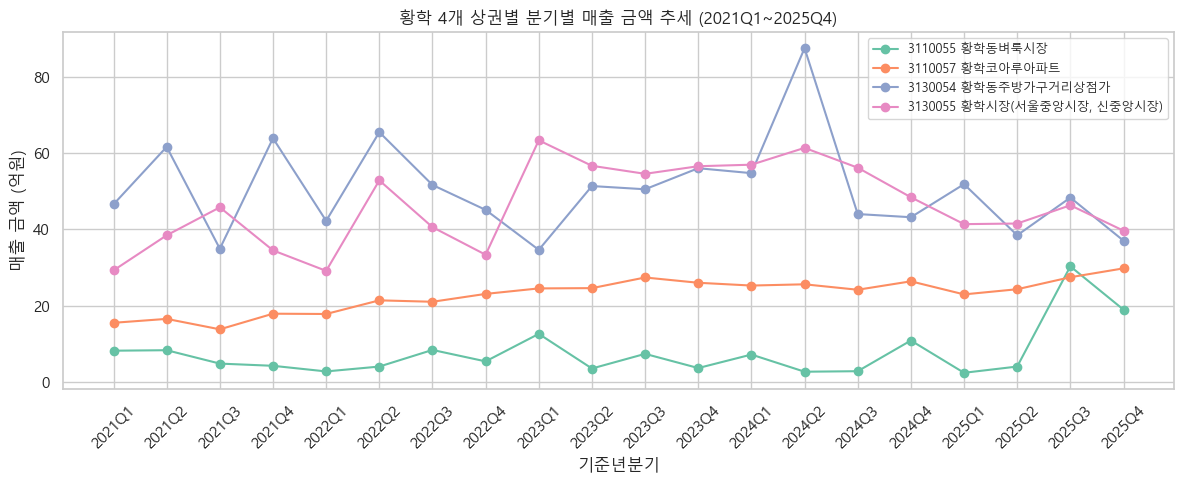

In [9]:
area_names_hwanghak = hwanghak_sales.drop_duplicates("상권_코드").set_index("상권_코드")["상권_코드_명"]

per_area_sales = hwanghak_sales.groupby(["기준_년분기_코드", "상권_코드"], as_index=False).agg(
    총매출금액=("당월_매출_금액", "sum")
)
per_area_sales = add_quarter_label(per_area_sales)
per_area_sales["상권_코드_명"] = per_area_sales["상권_코드"].map(area_names_hwanghak)

fig, ax = plt.subplots(figsize=(12, 5))
for i, code_ in enumerate(HWANGHAK_CODES):
    sub = per_area_sales[per_area_sales["상권_코드"] == code_].sort_values("분기_라벨")
    ax.plot(sub["분기_라벨"], sub["총매출금액"] / 1e8, marker="o",
            color=AREA_PALETTE[i], label=f"{code_} {area_names_hwanghak[code_]}")
ax.set_title("황학 4개 상권별 분기별 매출 금액 추세 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("매출 금액 (억원)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**해석:** 4개 상권의 2021년 대비 2025년 매출 변화율은 상권별로 크게 갈린다 — 황학동벼룩시장(3110055)
+117.7%, 황학코아루아파트(3110057) +63.9%, 황학시장(3130055) +14.1%로 모두 증가한 반면, 2021년
기준 황학동 4개 상권 매출의 약 46.6%를 차지하던 가장 큰 상권인 황학동주방가구거리상점가(3130054)만
유일하게 -15.1% 감소했다. 즉 황학동 합계 매출의 완만한 증가는 서로 다른 방향으로 움직이는 4개 상권이
섞여 만들어진 결과이며, 특정 한 상권이 전체 흐름을 일방적으로 주도한다고 보기는 어렵다.

### 6-3. 황학동 vs 서울 전체 추세

**집계 기준: 시계열 추세 비교(index화)**. 서울 전체 총매출과 황학동 총매출을 그대로 겹쳐 그리면 규모
차이 때문에 의미가 없으므로, 각 그룹의 "상권 1개당 평균 매출"을 계산한 뒤 `2021Q1 = 100` 기준으로
index화하여 두 그룹의 성장/감소 경로(추세의 방향과 기울기)만 비교한다.

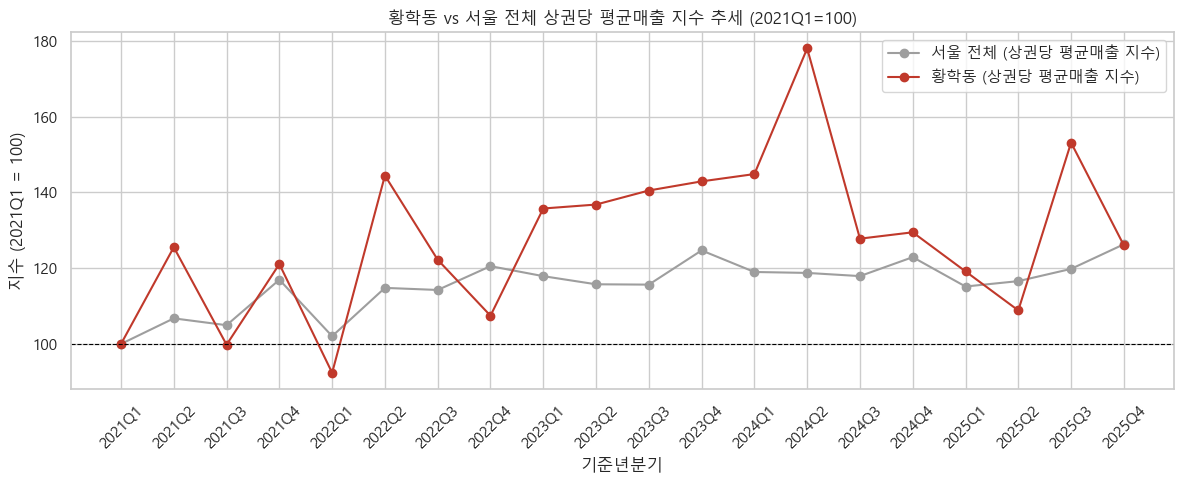

 분기_라벨      서울_지수      황학_지수
2021Q1 100.000000 100.000000
2021Q2 106.752809 125.521045
2021Q3 104.947936  99.796458
2021Q4 116.948382 121.083081
2022Q1 102.051233  92.388370
2022Q2 114.795165 144.429524
2022Q3 114.243142 122.213337
2022Q4 120.525668 107.450367
2023Q1 117.885858 135.738563
2023Q2 115.742685 136.779279
2023Q3 115.654966 140.486878
2023Q4 124.679272 142.896788
2024Q1 118.988143 144.824496
2024Q2 118.742785 177.966142
2024Q3 117.903215 127.779894
2024Q4 122.898731 129.459035
2025Q1 115.154972 119.146722
2025Q2 116.576453 108.850795
2025Q3 119.803190 153.114120
2025Q4 126.297607 126.016910


In [10]:
seoul_area_sales = sales.groupby(["기준_년분기_코드", "상권_코드"], as_index=False).agg(
    총매출금액=("당월_매출_금액", "sum")
)

seoul_avg_per_area = seoul_area_sales.groupby("기준_년분기_코드")["총매출금액"].mean().rename("서울_상권당_평균매출")
hwanghak_avg_per_area = per_area_sales.groupby("기준_년분기_코드")["총매출금액"].mean().rename("황학_상권당_평균매출")

sales_compare = pd.concat([seoul_avg_per_area, hwanghak_avg_per_area], axis=1).reset_index()
sales_compare = add_quarter_label(sales_compare).sort_values("분기_라벨")

base_q = QUARTER_ORDER[0]
base_seoul = sales_compare.loc[sales_compare["기준_년분기_코드"] == base_q, "서울_상권당_평균매출"].iloc[0]
base_hwanghak = sales_compare.loc[sales_compare["기준_년분기_코드"] == base_q, "황학_상권당_평균매출"].iloc[0]

sales_compare["서울_지수"] = sales_compare["서울_상권당_평균매출"] / base_seoul * 100
sales_compare["황학_지수"] = sales_compare["황학_상권당_평균매출"] / base_hwanghak * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sales_compare["분기_라벨"], sales_compare["서울_지수"], marker="o", color=SEOUL_COLOR, label="서울 전체 (상권당 평균매출 지수)")
ax.plot(sales_compare["분기_라벨"], sales_compare["황학_지수"], marker="o", color=HWANGHAK_COLOR, label="황학동 (상권당 평균매출 지수)")
ax.axhline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_title("황학동 vs 서울 전체 상권당 평균매출 지수 추세 (2021Q1=100)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("지수 (2021Q1 = 100)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print(sales_compare[["분기_라벨", "서울_지수", "황학_지수"]].to_string(index=False))

**해석:** 지수(2021Q1=100) 기준으로 보면 2025Q4에 서울 전체 지수는 126.3, 황학동 지수는 126.0으로
장기 성장률은 거의 비슷한 수준에서 마무리된다. 그러나 그 경로는 크게 다르다 — 서울 전체 지수는
95~126 사이의 비교적 좁은 범위에서 완만하게 움직인 반면, 황학동 지수는 83(2022Q1)~178(2024Q2) 사이를
오가며 훨씬 큰 변동성을 보였다. 즉 5년간의 최종 성장률 자체는 서울 평균과 크게 다르지 않지만, 그 과정의
분기별 변동성은 황학동이 서울 전체보다 뚜렷하게 크다.

### 6-4. YoY(전년 동기 대비) 변화

분기 데이터이므로 계절성을 고려해 QoQ보다 YoY를 주요 변화 지표로 사용한다. 2021년 분기들은 비교할
전년 데이터가 없으므로 YoY가 계산되지 않는 것(`NaN`)이 정상이다.

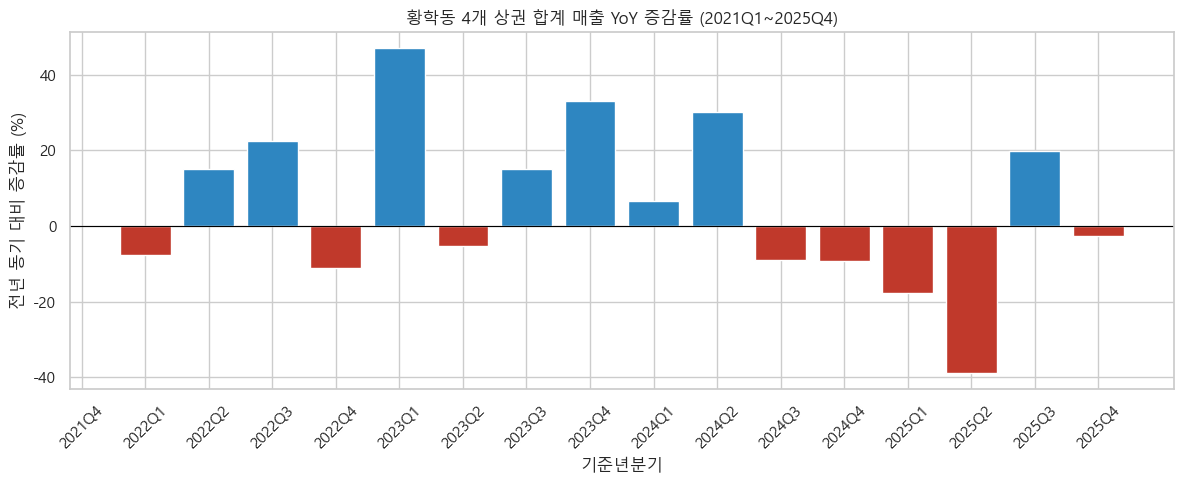

 분기_라벨       총매출금액  YoY_매출증감률(%)
2021Q1  9960896474           NaN
2021Q2 12503021304           NaN
2021Q3  9940621863           NaN
2021Q4 12060960355           NaN
2022Q1  9202709933     -7.611630
2022Q2 14386475400     15.063992
2022Q3 12173543979     22.462600
2022Q4 10703019867    -11.258975
2023Q1 13520777698     46.921698
2023Q2 13624442337     -5.296871
2023Q3 13993752516     14.952166
2023Q4 14233801113     32.988645
2024Q1 14425818155      6.693701
2024Q2 17727023191     30.111918
2024Q3 12728022938     -9.044962
2024Q4 12895280470     -9.403817
2025Q1 11868081636    -17.730270
2025Q2 10842514973    -38.836234
2025Q3 15251538955     19.826457
2025Q4 12552413927     -2.658853


In [11]:
hwanghak_quarterly_sales_sorted = hwanghak_quarterly_sales.sort_values("기준_년분기_코드").reset_index(drop=True)
hwanghak_quarterly_sales_sorted["YoY_매출증감률(%)"] = (
    hwanghak_quarterly_sales_sorted["총매출금액"].pct_change(periods=4) * 100
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2E86C1" if v >= 0 else "#C0392B" for v in hwanghak_quarterly_sales_sorted["YoY_매출증감률(%)"].fillna(0)]
ax.bar(hwanghak_quarterly_sales_sorted["분기_라벨"].astype(str), hwanghak_quarterly_sales_sorted["YoY_매출증감률(%)"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("황학동 4개 상권 합계 매출 YoY 증감률 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("전년 동기 대비 증감률 (%)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(hwanghak_quarterly_sales_sorted[["분기_라벨", "총매출금액", "YoY_매출증감률(%)"]].to_string(index=False))

**해석:** YoY 증감률은 -38.8%(2025Q2)에서 +46.9%(2023Q1)까지 매우 넓게 진동하며, 연속된 여러 분기에
걸쳐 한 방향으로만 감소하는 패턴은 관찰되지 않는다. 2021년 4개 분기의 YoY가 `NaN`인 것은 비교할 전년
데이터가 없기 때문이며 결측/오류가 아니다. 다만 YoY의 절대값이 클수록(예: -38.8%, +46.9%) 분기별
매출 규모 자체가 크지 않은 상권 합계 데이터에서는 특정 분기의 일시적 요인에 좌우된 결과일 수 있어,
이 변동을 곧바로 추세 전환으로 해석하지 않도록 주의한다.

## 7. 업종별 매출 구조 분석

업종이 63개(sales 기준)로 많으므로 모든 업종을 한 그래프에 표시하지 않고 **Top N 방식**을 사용한다.

**Top N 선정 기준**: `TOP_N = 10`, **황학동 4개 상권의 2021Q1~2025Q4 전체 기간 누적 매출금액** 기준
상위 10개 업종을 "주요 업종"으로 정의한다. 참고로 **최근 4개 분기(2025년)** 기준 상위 10개 업종도 함께
확인하여, 전체 기간 기준과 최근 기준의 주요 업종 구성이 달라졌는지도 살펴본다.

In [12]:
TOP_N = 10

category_total_all_period = (
    hwanghak_sales.groupby("서비스_업종_코드_명")["당월_매출_금액"].sum().sort_values(ascending=False)
)
top_categories_overall = category_total_all_period.head(TOP_N).index.tolist()

RECENT_QUARTERS_2025 = [20251, 20252, 20253, 20254]
category_total_recent = (
    hwanghak_sales[hwanghak_sales["기준_년분기_코드"].isin(RECENT_QUARTERS_2025)]
    .groupby("서비스_업종_코드_명")["당월_매출_금액"].sum().sort_values(ascending=False)
)
top_categories_recent = category_total_recent.head(TOP_N).index.tolist()

print(f"[전체 기간(2021Q1~2025Q4) 누적매출 기준 TOP {TOP_N} 업종]")
display(category_total_all_period.head(TOP_N).to_frame("누적_매출금액"))

print(f"\n[최근 4개 분기(2025년) 누적매출 기준 TOP {TOP_N} 업종]")
display(category_total_recent.head(TOP_N).to_frame("누적_매출금액"))

only_in_overall = [c for c in top_categories_overall if c not in top_categories_recent]
only_in_recent = [c for c in top_categories_recent if c not in top_categories_overall]
print("\n전체기간 TOP10에만 있고 최근 TOP10에는 없는 업종:", only_in_overall if only_in_overall else "없음")
print("최근 TOP10에만 있고 전체기간 TOP10에는 없는 업종:", only_in_recent if only_in_recent else "없음")

[전체 기간(2021Q1~2025Q4) 누적매출 기준 TOP 10 업종]


,누적_매출금액
서비스_업종_코드_명,
가구,85977732730
한식음식점,60408854166
육류판매,23607262235
슈퍼마켓,22760686534
치과의원,10991081124
전자상거래업,8992015967
일반의류,5774181942
가전제품,5084684996
반찬가게,4351110413



[최근 4개 분기(2025년) 누적매출 기준 TOP 10 업종]


,누적_매출금액
서비스_업종_코드_명,
한식음식점,13255368524
가구,12871718197
슈퍼마켓,5044367752
전자상거래업,4397284731
육류판매,2933577295
치과의원,1995844229
반찬가게,1513070356
호프-간이주점,1492049788
커피-음료,1118748875



전체기간 TOP10에만 있고 최근 TOP10에는 없는 업종: ['일반의류', '가전제품']
최근 TOP10에만 있고 전체기간 TOP10에는 없는 업종: ['커피-음료', '철물점']


**해석:** 전체 기간(2021Q1~2025Q4) 누적 매출 기준으로는 가구(약 860억원)가 1위, 한식음식점(약 604억원)이
2위였다. 그러나 최근 4개 분기(2025년) 기준으로는 순위가 뒤바뀌어 한식음식점(약 133억원)이 1위, 가구(약
129억원)가 2위로 내려온다. TOP 10 구성도 일부 바뀌어, 전체기간 TOP10에만 있던 일반의류·가전제품이
최근 TOP10에서는 빠지고 대신 커피-음료·철물점이 새로 진입했다. 즉 "가구(가구거리)가 황학동 매출을
대표하는 업종"이라는 인상은 전체 기간 누적 기준에서는 맞지만, 최근 구조에서는 이미 달라지고 있다.

### 7-1. 주요 업종 매출 추세

전체 기간 기준 TOP 10 업종(`top_categories_overall`)을 대상으로 분기별 매출 추세를 확인한다.
10개 업종을 한 그래프에 모두 겹치면 가독성이 떨어지므로, 소규모 다중 패널(subplot)로 나누어 표시한다.

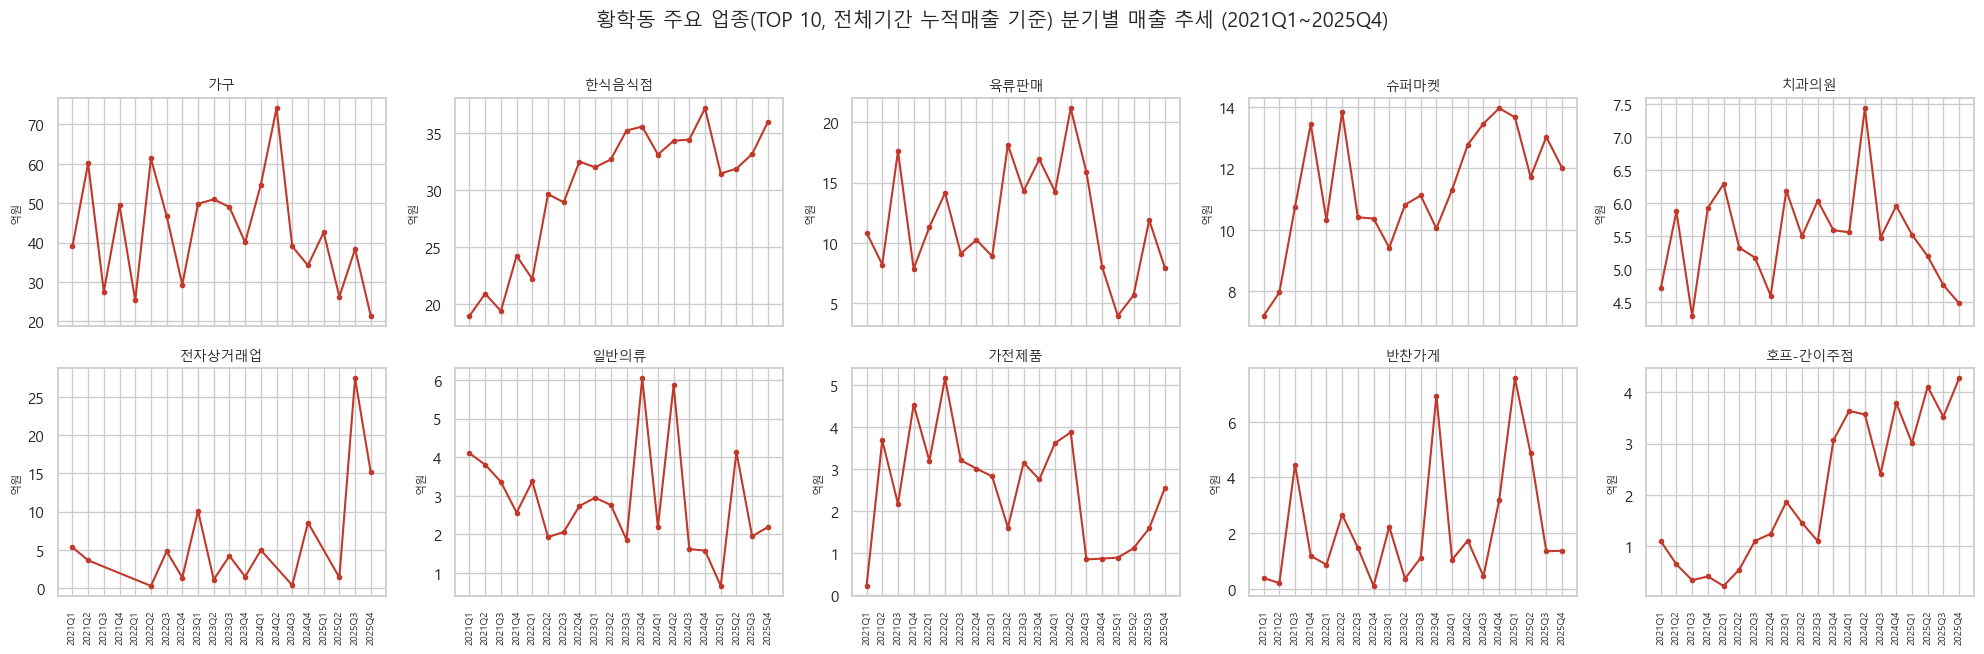

In [13]:
top_category_quarterly = (
    hwanghak_sales[hwanghak_sales["서비스_업종_코드_명"].isin(top_categories_overall)]
    .groupby(["기준_년분기_코드", "서비스_업종_코드_명"], as_index=False)["당월_매출_금액"].sum()
)
top_category_quarterly = add_quarter_label(top_category_quarterly)

n_cols = 5
n_rows = int(np.ceil(TOP_N / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows), sharex=True)
axes = axes.flatten()

for i, cat in enumerate(top_categories_overall):
    ax = axes[i]
    sub = top_category_quarterly[top_category_quarterly["서비스_업종_코드_명"] == cat].sort_values("분기_라벨")
    ax.plot(sub["분기_라벨"], sub["당월_매출_금액"] / 1e8, marker="o", markersize=3, color=HWANGHAK_COLOR)
    ax.set_title(cat, fontsize=10)
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.set_ylabel("억원", fontsize=8)

for j in range(len(top_categories_overall), len(axes)):
    axes[j].axis("off")

fig.suptitle(f"황학동 주요 업종(TOP {TOP_N}, 전체기간 누적매출 기준) 분기별 매출 추세 (2021Q1~2025Q4)", y=1.02)
plt.tight_layout()
plt.show()

**해석:** TOP 10 업종의 분기별 궤적은 업종마다 다르다. 가구는 등락은 있지만 전체적으로 완만히 줄어드는
흐름(2021년 대비 2025년 -26.9%)인 반면, 한식음식점은 뚜렷한 증가(+58.8%) 추세를 보인다. 전자상거래업과
호프-간이주점은 절대 규모는 작지만 각각 +393%, +501%로 급격히 성장했다(다만 2021년 기준 금액 자체가
작아 증가율이 크게 나타나는 점에 유의해야 한다). 슈퍼마켓은 +28.2%로 완만한 성장세를 보였다. 10개 업종을
하나의 방향으로 요약하기는 어렵고, 업종별로 성장·정체·감소가 혼재되어 있다.

### 7-2. 초기 vs 최근 업종 구조 비교

**비교 기준: 2021년(4개 분기 합계) vs 2025년(4개 분기 합계)**. 단일 분기(예: 2021Q1 vs 2025Q4)는
계절적 변동이나 특정 분기의 우연한 값에 영향을 받을 수 있으므로, 1년 전체를 합산해 구조 변화를 비교한다.
TOP 10 업종 + 나머지("그 외")로 구성비를 나누어 표시한다.

,업종,2021_비중(%),2025_비중(%)
0,가구,39.617833,25.481210
1,한식음식점,18.776845,26.240694
2,육류판매,9.999134,5.807391
3,슈퍼마켓,8.848513,9.985970
4,치과의원,4.678750,3.951028
5,전자상거래업,2.005654,8.704987
6,일반의류,3.109967,1.769915
7,가전제품,2.384243,1.217114
8,반찬가게,1.402570,2.995316
9,호프-간이주점,0.558752,2.953703


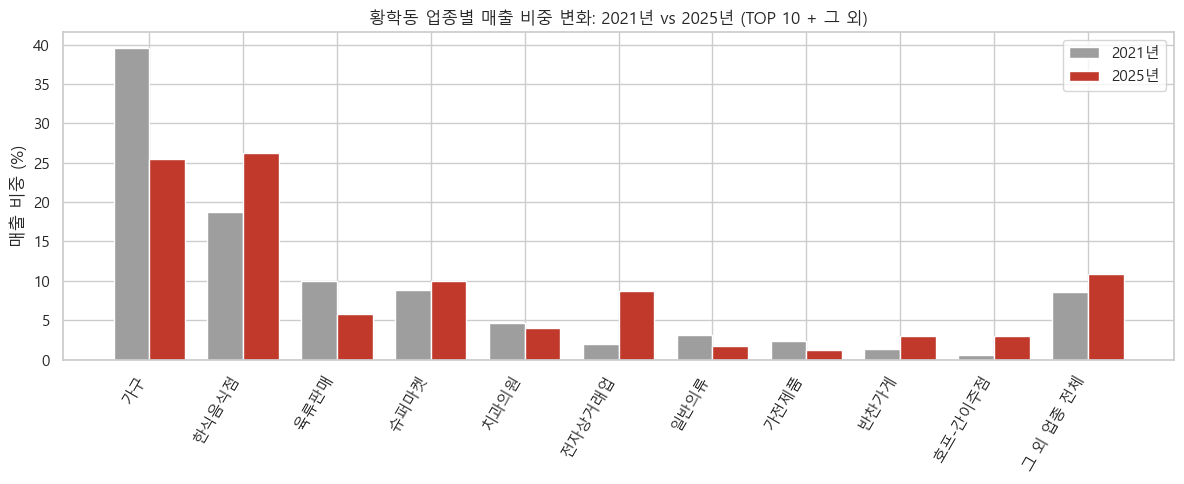

In [14]:
sales_2021 = hwanghak_sales[hwanghak_sales["기준_년분기_코드"].between(20211, 20214)]
sales_2025 = hwanghak_sales[hwanghak_sales["기준_년분기_코드"].between(20251, 20254)]

cat_2021 = sales_2021.groupby("서비스_업종_코드_명")["당월_매출_금액"].sum()
cat_2025 = sales_2025.groupby("서비스_업종_코드_명")["당월_매출_금액"].sum()

total_2021 = cat_2021.sum()
total_2025 = cat_2025.sum()

comp_rows = []
for cat in top_categories_overall:
    comp_rows.append({
        "업종": cat,
        "2021_비중(%)": cat_2021.get(cat, 0) / total_2021 * 100,
        "2025_비중(%)": cat_2025.get(cat, 0) / total_2025 * 100,
    })
etc_2021 = 100 - sum(r["2021_비중(%)"] for r in comp_rows)
etc_2025 = 100 - sum(r["2025_비중(%)"] for r in comp_rows)
comp_rows.append({"업종": "그 외 업종 전체", "2021_비중(%)": etc_2021, "2025_비중(%)": etc_2025})

comp_df = pd.DataFrame(comp_rows)
display(comp_df)

x = np.arange(len(comp_df))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, comp_df["2021_비중(%)"], width, label="2021년", color=SEOUL_COLOR)
ax.bar(x + width / 2, comp_df["2025_비중(%)"], width, label="2025년", color=HWANGHAK_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(comp_df["업종"], rotation=60, ha="right")
ax.set_ylabel("매출 비중 (%)")
ax.set_title("황학동 업종별 매출 비중 변화: 2021년 vs 2025년 (TOP 10 + 그 외)")
ax.legend()
plt.tight_layout()
plt.show()

**해석:** 2021년 대비 2025년 업종 비중 변화에서 가장 큰 변화는 가구의 비중 축소(39.6% -> 25.5%,
-14.1%p)와 한식음식점의 비중 확대(18.8% -> 26.2%, +7.5%p)다. 전자상거래업도 2.0% -> 8.7%(+6.7%p)로
비중이 크게 늘었다. "그 외 업종 전체"의 비중도 8.6% -> 10.9%로 늘어, TOP 10에 들지 않는 소규모 업종들의
존재감도 함께 커지고 있다. 종합하면 가구 단일 업종에 대한 의존도가 뚜렷하게 낮아지고, 음식점·온라인
판매 등으로 매출 구성이 다변화되는 방향이 확인된다.

### 7-3. 업종별 변화 (초기 대비 최근, 비중 변화)

전체 업종(TOP 10에 한정하지 않음)을 대상으로 2021년 대비 2025년 매출 변화와 비중 변화를 계산한다.
다만 아직 이를 "성장 업종"/"쇠퇴 업종"으로 공식 라벨링하지 않는다. 매출 규모가 매우 작은 업종은
변화율(%)이 분모가 작아 과장되게 나타날 수 있으므로, 절대 금액 변화와 비중 변화(%p)를 함께 확인한다.

In [15]:
category_change = pd.DataFrame({
    "2021_매출금액": cat_2021,
    "2025_매출금액": cat_2025,
}).fillna(0)

category_change["금액_변화"] = category_change["2025_매출금액"] - category_change["2021_매출금액"]
category_change["증감률(%)"] = np.where(
    category_change["2021_매출금액"] > 0,
    category_change["금액_변화"] / category_change["2021_매출금액"] * 100,
    np.nan,
)
category_change["2021_비중(%)"] = category_change["2021_매출금액"] / total_2021 * 100
category_change["2025_비중(%)"] = category_change["2025_매출금액"] / total_2025 * 100
category_change["비중_변화(%p)"] = category_change["2025_비중(%)"] - category_change["2021_비중(%)"]

print("[2021년 매출 규모가 작아(하위 25%) 증감률 해석에 주의가 필요한 업종 수]")
small_base_threshold = category_change["2021_매출금액"].quantile(0.25)
print("2021 매출금액 하위 25% 기준값:", small_base_threshold)
print("해당 업종 수:", int((category_change["2021_매출금액"] <= small_base_threshold).sum()),
      "/ 전체", len(category_change))

print("\n[금액 기준 절대 증가 상위 10개 업종]")
display(category_change.sort_values("금액_변화", ascending=False).head(10)
        [["2021_매출금액", "2025_매출금액", "금액_변화", "증감률(%)", "비중_변화(%p)"]])

print("\n[금액 기준 절대 감소 상위 10개 업종]")
display(category_change.sort_values("금액_변화", ascending=True).head(10)
        [["2021_매출금액", "2025_매출금액", "금액_변화", "증감률(%)", "비중_변화(%p)"]])

print("\n[비중 변화(%p) 상위 10개 업종 - 비중이 커진 업종]")
display(category_change.sort_values("비중_변화(%p)", ascending=False).head(10)
        [["2021_비중(%)", "2025_비중(%)", "비중_변화(%p)"]])

print("\n[비중 변화(%p) 하위 10개 업종 - 비중이 작아진 업종]")
display(category_change.sort_values("비중_변화(%p)", ascending=True).head(10)
        [["2021_비중(%)", "2025_비중(%)", "비중_변화(%p)"]])

[2021년 매출 규모가 작아(하위 25%) 증감률 해석에 주의가 필요한 업종 수]
2021 매출금액 하위 25% 기준값: 123278262.0
해당 업종 수: 7 / 전체 27

[금액 기준 절대 증가 상위 10개 업종]


,2021_매출금액,2025_매출금액,금액_변화,증감률(%),비중_변화(%p)
서비스_업종_코드_명,,,,,
한식음식점,8.349218e+09,1.325537e+10,4.906151e+09,58.761797,7.463849
전자상거래업,8.918243e+08,4.397285e+09,3.505460e+09,393.066273,6.699332
호프-간이주점,2.484519e+08,1.492050e+09,1.243598e+09,500.538771,2.394951
커피-음료,0.000000e+00,1.118749e+09,1.118749e+09,NaN,2.214706
슈퍼마켓,3.934536e+09,5.044368e+09,1.109832e+09,28.207452,1.137457
반찬가게,6.236598e+08,1.513070e+09,8.894106e+08,142.611507,1.592746
세탁소,1.611695e+08,7.905761e+08,6.294066e+08,390.524711,1.202587
철물점,4.728994e+08,9.642207e+08,4.913213e+08,103.895527,0.845278
청과상,3.678332e+08,7.128908e+08,3.450575e+08,93.808145,0.584025



[금액 기준 절대 감소 상위 10개 업종]


,2021_매출금액,2025_매출금액,금액_변화,증감률(%),비중_변화(%p)
서비스_업종_코드_명,,,,,
가구,1.761627e+10,1.287172e+10,-4.744549e+09,-26.932773,-14.136624
육류판매,4.446165e+09,2.933577e+09,-1.512588e+09,-34.020052,-4.191743
일반의류,1.382863e+09,8.940646e+08,-4.887980e+08,-35.346823,-1.340052
가전제품,1.060166e+09,6.148196e+08,-4.453460e+08,-42.007210,-1.167129
편의점,7.400723e+08,3.093754e+08,-4.306968e+08,-58.196594,-1.051926
완구,3.836531e+08,0.000000e+00,-3.836531e+08,-100.000000,-0.862811
여관,4.224662e+08,2.919892e+08,-1.304769e+08,-30.884587,-0.372069
치과의원,2.080429e+09,1.995844e+09,-8.458516e+07,-4.065755,-0.727721
노래방,5.849869e+07,0.000000e+00,-5.849869e+07,-100.000000,-0.131560



[비중 변화(%p) 상위 10개 업종 - 비중이 커진 업종]


,2021_비중(%),2025_비중(%),비중_변화(%p)
서비스_업종_코드_명,,,
한식음식점,18.776845,26.240694,7.463849
전자상거래업,2.005654,8.704987,6.699332
호프-간이주점,0.558752,2.953703,2.394951
커피-음료,0.000000,2.214706,2.214706
반찬가게,1.402570,2.995316,1.592746
세탁소,0.362460,1.565046,1.202587
슈퍼마켓,8.848513,9.985970,1.137457
철물점,1.063520,1.908798,0.845278
청과상,0.827233,1.411258,0.584025



[비중 변화(%p) 하위 10개 업종 - 비중이 작아진 업종]


,2021_비중(%),2025_비중(%),비중_변화(%p)
서비스_업종_코드_명,,,
가구,39.617833,25.481210,-14.136624
육류판매,9.999134,5.807391,-4.191743
일반의류,3.109967,1.769915,-1.340052
가전제품,2.384243,1.217114,-1.167129
편의점,1.664374,0.612448,-1.051926
완구,0.862811,0.000000,-0.862811
치과의원,4.678750,3.951028,-0.727721
여관,0.950099,0.578030,-0.372069
분식전문점,1.191215,1.041865,-0.149350


**해석:** 절대 금액 기준으로는 한식음식점(+49.1억원)과 전자상거래업(+35.1억원)의 증가가 가장 크고,
가구(-47.4억원)와 육류판매(-15.1억원)의 감소가 가장 크다. 완구·노래방·치킨전문점은 2025년 기준 매출이
0으로 나타나 사실상 황학동 4개 상권에서 해당 업종이 사라진 것으로 보이나, 이 업종들은 2021년 매출
규모 자체가 매우 작았던 업종(2021년 매출금액 하위 25% 기준값 약 1.23억원에 해당하는 27개 업종 중 7개)
이므로 "완전히 사라졌다"는 사실 자체는 기록하되, 이를 상권 전체의 쇠퇴 신호로 과도하게 확대 해석하지
않는다. 아직 이 업종들을 "성장/쇠퇴 업종"으로 공식 분류하지 않고, 사실관계만 남겨둔다.

## 8. 주중/주말 소비 구조 분석

`sales`에는 `주중_매출_금액`, `주말_매출_금액` 컬럼이 있다. 구성비 계산 전, `주중_매출_금액 + 주말_매출_금액`을
분모로 사용하는 방식이 데이터 구조상 타당한지(즉 두 값의 합이 `당월_매출_금액`과 일관되는지) 먼저 확인한다.

In [16]:
weekday_weekend_diff = sales["당월_매출_금액"] - (sales["주중_매출_금액"] + sales["주말_매출_금액"])
exact_ratio = (weekday_weekend_diff == 0).mean() * 100
print(f"[sales 전체] 당월_매출_금액 vs (주중_매출_금액 + 주말_매출_금액) 완전 일치 비율: {exact_ratio:.2f}%")
print("차이의 중앙값:", weekday_weekend_diff.median(), "/ 절대 차이의 중앙값:", weekday_weekend_diff.abs().median())
print("최대 절대 차이:", weekday_weekend_diff.abs().max())

[sales 전체] 당월_매출_금액 vs (주중_매출_금액 + 주말_매출_금액) 완전 일치 비율: 100.00%
차이의 중앙값: 0.0 / 절대 차이의 중앙값: 0.0
최대 절대 차이: 0


**해석:** `당월_매출_금액`과 `주중_매출_금액 + 주말_매출_금액`의 완전 일치 비율이 100.00%(최대 절대
차이 0원)로 확인되어, 시간대별 합계와 마찬가지로 두 값의 합을 분모로 사용하는 것이 데이터 구조상 타당하다.
따라서 아래 주중/주말 비중은 `02`의 성별·연령대 매출처럼 별도의 안전한 분모를 고민할 필요 없이,
`주중_매출_금액 + 주말_매출_금액`을 그대로 분모로 사용해 계산한다.

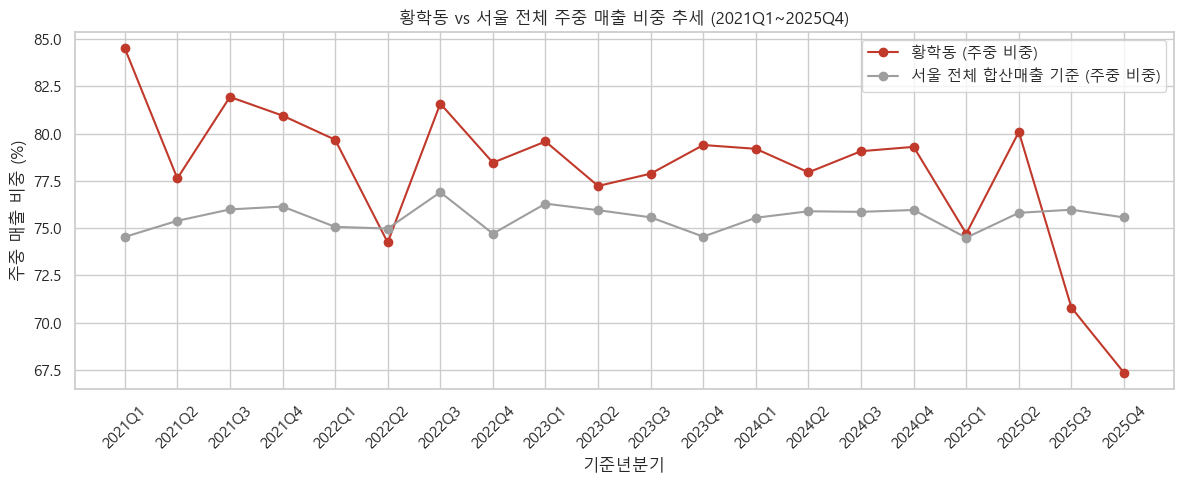

In [17]:
weekday_quarterly = hwanghak_sales.groupby("기준_년분기_코드", as_index=False).agg(
    주중=("주중_매출_금액", "sum"),
    주말=("주말_매출_금액", "sum"),
)
weekday_quarterly["주중_비중(%)"] = weekday_quarterly["주중"] / (weekday_quarterly["주중"] + weekday_quarterly["주말"]) * 100
weekday_quarterly["주말_비중(%)"] = 100 - weekday_quarterly["주중_비중(%)"]
weekday_quarterly = add_quarter_label(weekday_quarterly).sort_values("분기_라벨")

seoul_weekday_quarterly = sales.groupby("기준_년분기_코드", as_index=False).agg(
    주중=("주중_매출_금액", "sum"),
    주말=("주말_매출_금액", "sum"),
)
seoul_weekday_quarterly["주중_비중(%)"] = (
    seoul_weekday_quarterly["주중"] / (seoul_weekday_quarterly["주중"] + seoul_weekday_quarterly["주말"]) * 100
)
seoul_weekday_quarterly = add_quarter_label(seoul_weekday_quarterly).sort_values("분기_라벨")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekday_quarterly["분기_라벨"], weekday_quarterly["주중_비중(%)"], marker="o",
        color=HWANGHAK_COLOR, label="황학동 (주중 비중)")
ax.plot(seoul_weekday_quarterly["분기_라벨"], seoul_weekday_quarterly["주중_비중(%)"], marker="o",
        color=SEOUL_COLOR, label="서울 전체 합산매출 기준 (주중 비중)")
ax.set_title("황학동 vs 서울 전체 주중 매출 비중 추세 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("주중 매출 비중 (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

**해석:** 황학동 4개 상권 합계 주말 매출 비중은 2021년 18.96%에서 2025년 27.14%로 뚜렷하게 상승했다
(+8.18%p, 상대 기준 +43%). 반면 같은 기간 **서울 전체 합산 매출 기준** 주말 비중은 24.46% -> 24.53%로
사실상 변화가 없었다. 다만 이 서울 쪽 수치는 서울 전체 매출을 그대로 합산해서 계산한 값이라 매출 규모가
큰 상권에 가중치가 실리는 값이며, "서울의 평균적인 개별 상권"이 실제로 얼마나 주말 중심인지와는 다른
개념일 수 있다. 이 차이는 아래에서 서울 개별 상권 분포 기준으로 별도 확인한다.

이 합산 기준으로 보면, 황학동은 원래(2021년) 서울 전체 합산 기준보다 주중(평일) 중심 소비 비중이 높은
상권이었다가, 2025년에는 오히려 이 기준보다 주말 소비 비중이 더 높은 상권으로 바뀌었다. 이는 서울 전체의
공통된 추세가 아니라 황학동에 비교적 뚜렷하게 나타나는 변화로 보인다.

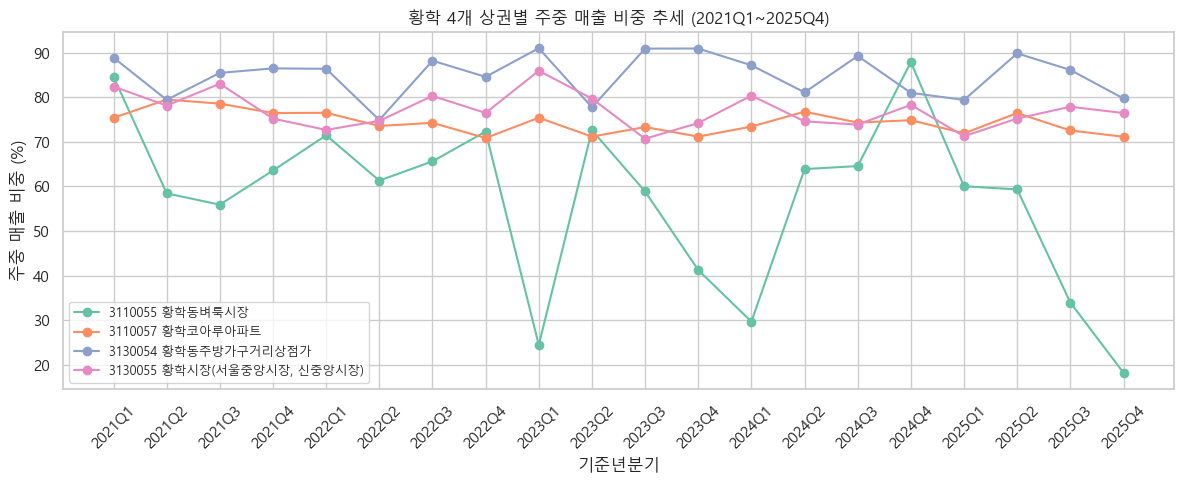

In [18]:
per_area_weekday = hwanghak_sales.groupby(["기준_년분기_코드", "상권_코드"], as_index=False).agg(
    주중=("주중_매출_금액", "sum"), 주말=("주말_매출_금액", "sum"),
)
per_area_weekday["주중_비중(%)"] = per_area_weekday["주중"] / (per_area_weekday["주중"] + per_area_weekday["주말"]) * 100
per_area_weekday = add_quarter_label(per_area_weekday)

fig, ax = plt.subplots(figsize=(12, 5))
for i, code_ in enumerate(HWANGHAK_CODES):
    sub = per_area_weekday[per_area_weekday["상권_코드"] == code_].sort_values("분기_라벨")
    ax.plot(sub["분기_라벨"], sub["주중_비중(%)"], marker="o", color=AREA_PALETTE[i],
            label=f"{code_} {area_names_hwanghak[code_]}")
ax.set_title("황학 4개 상권별 주중 매출 비중 추세 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("주중 매출 비중 (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**해석:** 상권별로 보면 주말 비중 상승은 특정 상권이 주도한다. 황학동벼룩시장은 32.8% -> 68.4%로 아예
주말 중심 상권으로 전환되었고, 황학코아루아파트(22.6%->27.1%)·황학시장(20.2%->24.7%)도 함께 상승했다.
반면 황학동주방가구거리상점가는 15.3%->16.4%로 거의 변화가 없어, 여전히 평일(도매) 중심 영업 패턴을
유지하고 있다. 즉 "주말 소비 증가"는 황학동 4개 상권의 공통 현상이라기보다, 벼룩시장을 비롯한 일부 상권에서
두드러지는 변화다.

### 서울 개별 상권 분포 기준 비교

앞선 그래프의 "서울 전체" 주중/주말 비중은 서울 전체 매출을 합산한 뒤 주중/주말로 나눈 값이므로,
매출 규모가 큰 상권의 영향을 크게 받는 **서울 전체 합산 매출 기준** 비중이다. 이는 "서울의 평균적인
개별 상권"이 실제로 얼마나 주말 중심인지와는 다른 개념일 수 있다. 이를 보완하기 위해 서울의 각 상권에
대해 먼저 `주말 매출 / (주중 매출 + 주말 매출)`을 상권 단위로 계산한 뒤, 이 **개별 상권 분포**의
median·Q1·Q3와 황학 4개 상권의 위치(percentile)를 확인한다.

In [19]:
def per_area_weekend_share(df, q_start, q_end):
    """상권별로 먼저 (주말 매출 / (주중+주말 매출))을 계산한다. 매출이 없는(분모 0) 상권은 제외한다."""
    sub = df[df["기준_년분기_코드"].between(q_start, q_end)]
    g = sub.groupby("상권_코드").agg(주중=("주중_매출_금액", "sum"), 주말=("주말_매출_금액", "sum"))
    denom = g["주중"] + g["주말"]
    g = g[denom > 0].copy()
    g["주말_비중(%)"] = g["주말"] / (g["주중"] + g["주말"]) * 100
    return g["주말_비중(%)"]


seoul_area_weekend_2021 = per_area_weekend_share(sales, 20211, 20214)
seoul_area_weekend_2025 = per_area_weekend_share(sales, 20251, 20254)

dist_summary = pd.DataFrame({
    "2021": seoul_area_weekend_2021.quantile([0.25, 0.5, 0.75]),
    "2025": seoul_area_weekend_2025.quantile([0.25, 0.5, 0.75]),
})
dist_summary.index = ["Q1 (25%)", "중앙값(50%)", "Q3 (75%)"]
print("[서울 개별 상권 단위로 먼저 계산한 주말 매출 비중의 분포]")
display(dist_summary.round(2))

print("\n[황학 4개 상권이 이 개별 상권 분포 안에서 차지하는 위치]")
for code_ in HWANGHAK_CODES:
    for year_label, series in [("2021", seoul_area_weekend_2021), ("2025", seoul_area_weekend_2025)]:
        if code_ not in series.index:
            print(f"  {year_label} - {code_} {area_names_hwanghak[code_]}: 해당 연도 매출 데이터 없음")
            continue
        val = series.loc[code_]
        pct = (series < val).mean() * 100
        print(f"  {year_label} - {code_} {area_names_hwanghak[code_]}: 주말비중={val:.1f}%, "
              f"서울 개별 상권 분포 내 하위 {pct:.1f}% 지점")

[서울 개별 상권 단위로 먼저 계산한 주말 매출 비중의 분포]


,2021,2025
Q1 (25%),19.93,19.91
중앙값(50%),24.89,24.81
Q3 (75%),29.08,29.24



[황학 4개 상권이 이 개별 상권 분포 안에서 차지하는 위치]
  2021 - 3110055 황학동벼룩시장: 주말비중=32.8%, 서울 개별 상권 분포 내 하위 89.0% 지점
  2025 - 3110055 황학동벼룩시장: 주말비중=68.4%, 서울 개별 상권 분포 내 하위 99.9% 지점
  2021 - 3110057 황학코아루아파트: 주말비중=22.6%, 서울 개별 상권 분포 내 하위 36.6% 지점
  2025 - 3110057 황학코아루아파트: 주말비중=27.1%, 서울 개별 상권 분포 내 하위 63.5% 지점
  2021 - 3130054 황학동주방가구거리상점가: 주말비중=15.3%, 서울 개별 상권 분포 내 하위 13.5% 지점
  2025 - 3130054 황학동주방가구거리상점가: 주말비중=16.4%, 서울 개별 상권 분포 내 하위 15.9% 지점
  2021 - 3130055 황학시장(서울중앙시장, 신중앙시장): 주말비중=20.2%, 서울 개별 상권 분포 내 하위 26.2% 지점
  2025 - 3130055 황학시장(서울중앙시장, 신중앙시장): 주말비중=24.7%, 서울 개별 상권 분포 내 하위 49.4% 지점


**해석:** 서울 개별 상권 단위로 먼저 비중을 구해도 median은 2021년 24.89% -> 2025년 24.81%로 거의
변화가 없다(Q1도 19.93%->19.91%, Q3도 29.08%->29.24%로 안정적). 즉 서울 전체 합산 기준뿐 아니라
개별 상권 분포 기준으로 봐도, 서울 "전형적인 상권"의 주말 비중은 5년간 거의 바뀌지 않았다.

반면 황학 4개 상권이 이 분포 안에서 차지하는 위치는 크게 달라졌다. 황학동벼룩시장은 2021년에도 이미
상위권(하위 89.0% 지점)이었으나 2025년에는 서울 상권 중 거의 최상위(하위 99.9% 지점)로 올라섰고,
황학코아루아파트는 중위권 이하(36.6%)에서 중위권 이상(63.5%)으로, 황학시장도 26.2%에서 49.4%로
중앙값에 근접하는 수준까지 올라왔다. 황학동주방가구거리상점가만 13.5%->15.9%로 여전히 하위권에
머물렀다. 종합하면 주말 소비 비중 확대는 서울 전체의 일반적인 변화가 아니라, 황학동 4개 상권(특히
벼룩시장·코아루아파트·황학시장)이 서울 상권 분포 안에서 상대적으로 훨씬 더 주말 중심으로 이동한,
황학동에 비교적 강하게 나타난 변화로 해석된다.

## 9. 시간대별 소비 구조 분석

`02_preprocessing.ipynb`에서 sales의 시간대별 매출금액 합계(`시간대_00~06_매출_금액`~`시간대_21~24_매출_금액`)가
`당월_매출_금액`과 매우 높은 수준(100.00% 일치)으로 일관됨을 확인했으므로, 이 컬럼들을 구성비 분석에
적극 활용한다. 분기(x축) × 시간대(y축) × 매출 비중(값) 형태의 heatmap으로 변화를 확인한다.

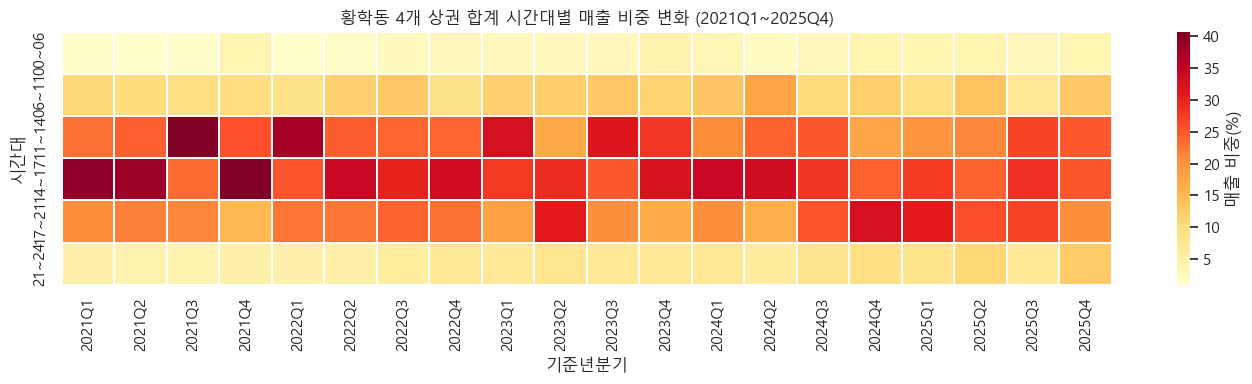

In [20]:
TIME_AMOUNT_COLS = [
    "시간대_00~06_매출_금액", "시간대_06~11_매출_금액", "시간대_11~14_매출_금액",
    "시간대_14~17_매출_금액", "시간대_17~21_매출_금액", "시간대_21~24_매출_금액",
]
TIME_LABELS = [c.replace("시간대_", "").replace("_매출_금액", "") for c in TIME_AMOUNT_COLS]

time_quarterly = hwanghak_sales.groupby("기준_년분기_코드")[TIME_AMOUNT_COLS].sum()
time_share = time_quarterly.div(time_quarterly.sum(axis=1), axis=0) * 100
time_share.columns = TIME_LABELS
time_share.index = [QUARTER_LABEL_MAP[q] for q in time_share.index]
time_share_T = time_share.T

plt.figure(figsize=(14, 4))
sns.heatmap(time_share_T, cmap="YlOrRd", cbar_kws={"label": "매출 비중(%)"}, linewidths=0.3)
plt.title("황학동 4개 상권 합계 시간대별 매출 비중 변화 (2021Q1~2025Q4)")
plt.xlabel("기준년분기")
plt.ylabel("시간대")
plt.tight_layout()
plt.show()

**해석:** 낮 시간대(11~14시, 14~17시) 비중의 합은 2021년 63.8%에서 2025년 50.0%로 줄었고, 저녁·심야
시간대(17~21시, 21~24시) 비중의 합은 24.3%에서 35.6%로 늘었다. 특히 21~24시 비중은 4.8% -> 9.6%로
두 배 가까이 커졌다. 앞서 확인한 주말 비중 상승과 같은 방향으로, 낮 중심에서 저녁·야간 중심으로 소비
시간대가 이동하는 패턴이 확인된다.

황학 4개 상권 각각의 시간대 구조가 같은 방향으로 움직이는지 확인하기 위해 상권별 heatmap을 나란히 비교한다.
상권 간 직접적인 색상 비교가 가능하도록, 4개 heatmap 모두 실제 데이터의 최소·최대 비중을 기준으로 계산한
동일한 `vmin`/`vmax`와 동일한 colormap을 적용한다.

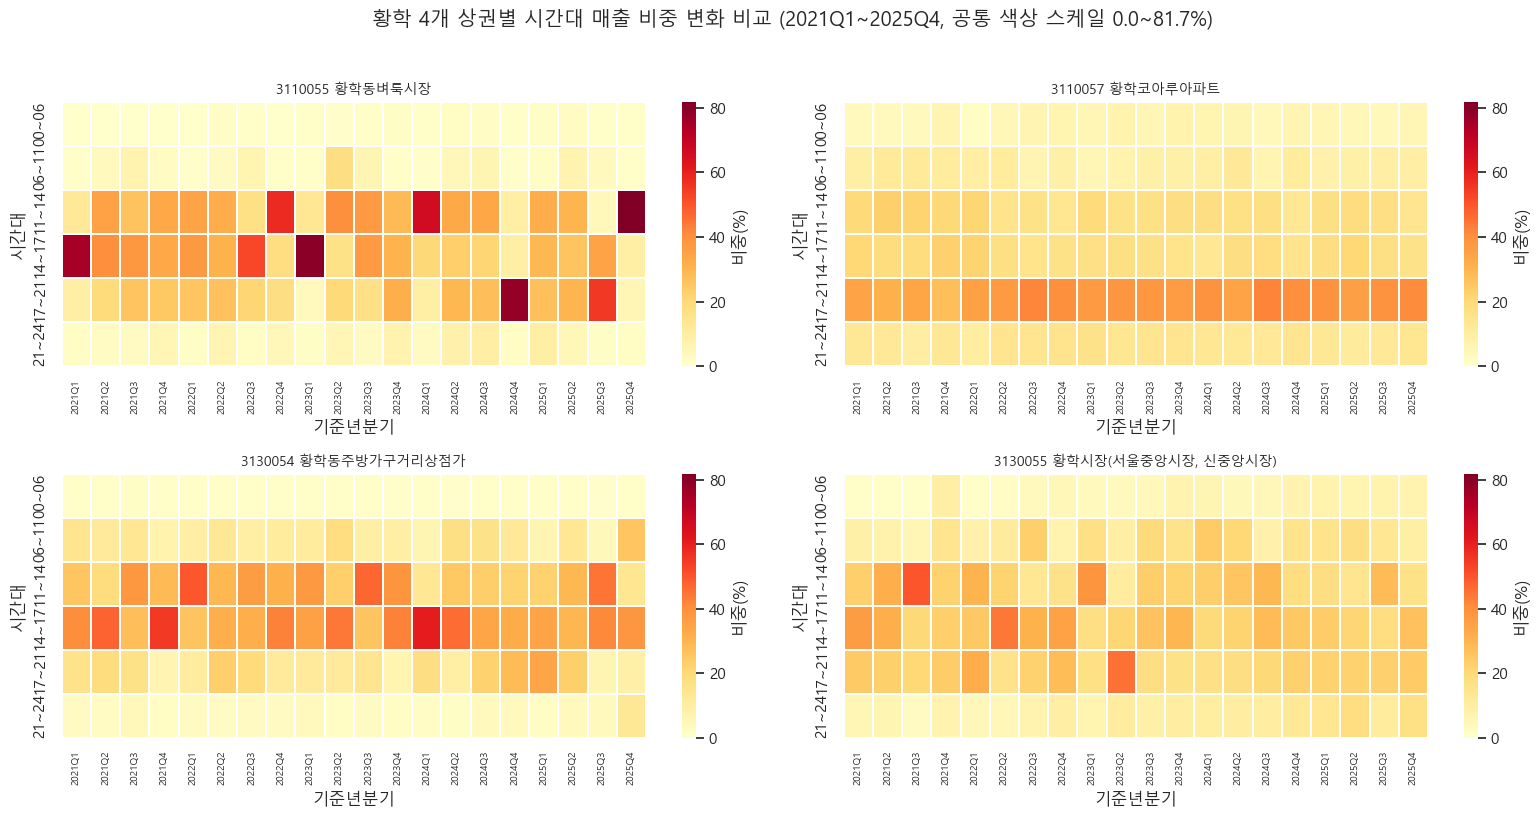

In [21]:
area_time_shares = {}
for code_ in HWANGHAK_CODES:
    area_df = hwanghak_sales[hwanghak_sales["상권_코드"] == code_]
    area_time_q = area_df.groupby("기준_년분기_코드")[TIME_AMOUNT_COLS].sum()
    area_time_share = area_time_q.div(area_time_q.sum(axis=1), axis=0) * 100
    area_time_share.columns = TIME_LABELS
    area_time_share.index = [QUARTER_LABEL_MAP[q] for q in area_time_share.index]
    area_time_shares[code_] = area_time_share

# 4개 heatmap이 동일한 색상 기준으로 비교되도록, 실제 데이터의 최소/최대 비중을 공통 vmin/vmax로 사용한다.
# (80%처럼 임의의 값을 고정하지 않고, 4개 상권 데이터에서 실제로 관측된 최소/최대값을 그대로 사용한다.)
shared_vmin = min(share.values.min() for share in area_time_shares.values())
shared_vmax = max(share.values.max() for share in area_time_shares.values())

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for i, code_ in enumerate(HWANGHAK_CODES):
    sns.heatmap(area_time_shares[code_].T, cmap="YlOrRd", ax=axes[i], cbar=True,
                vmin=shared_vmin, vmax=shared_vmax,
                cbar_kws={"label": "비중(%)"}, linewidths=0.2)
    axes[i].set_title(f"{code_} {area_names_hwanghak[code_]}", fontsize=10)
    axes[i].set_xlabel("기준년분기")
    axes[i].set_ylabel("시간대")
    axes[i].tick_params(axis="x", labelsize=7, rotation=90)

fig.suptitle(
    f"황학 4개 상권별 시간대 매출 비중 변화 비교 (2021Q1~2025Q4, 공통 색상 스케일 "
    f"{shared_vmin:.1f}~{shared_vmax:.1f}%)",
    y=1.02,
)
plt.tight_layout()
plt.show()

**해석:** 4개 상권의 시간대 구조는 서로 다르다. 황학동주방가구거리상점가는 14~17시 비중이 가장 크고
(약 39.5%) 시간대 구조가 비교적 안정적으로 유지되어 여전히 도매 영업시간 특성이 강하다. 황학코아루아파트는
17~21시 비중이 가장 크며(약 37.6%) 00~06시·21~24시 비중도 상대적으로 높아 야간 소비 성격이 뚜렷하다.
황학동벼룩시장은 11~17시(낮) 비중이 가장 높다(합계 약 65.1%). 즉 앞서 확인한 "낮 -> 저녁/야간 이동"은
황학동 4개 상권의 평균적 현상이며, 그 이면에는 상권별로 상당히 다른 시간대 특성이 존재한다.

## 10. 연령대별 소비 구조 분석

**주의 (반드시 고려)**: `02_preprocessing.ipynb` 섹션 14에서 sales의 연령대별 매출금액 합계와
`당월_매출_금액`이 완전히 일치하는 행은 약 40.95%에 불과했고, 최대 절대 차이가 약 4,642억 원에 달하는
사례도 있었다(원인은 집계 기준/추정 방식 차이로 추정되나 확정할 근거는 없음). 시간대별 합계(100% 일치)와는
분명히 다른 상황이다.

따라서 이 노트북에서는 연령대별 비중을 계산할 때 **`당월_매출_금액`을 분모로 사용하지 않고**,
**연령대별 매출금액 6개 컬럼의 합계 자체를 분모로 사용**한다. 이렇게 하면 "연령대 구성 내부의 상대적 비중"은
안전하게 비교할 수 있지만, 그 합계가 `당월_매출_금액`과 정확히 같은 모수인지는 보장하지 않는다는 한계를
함께 인지하고 해석한다.

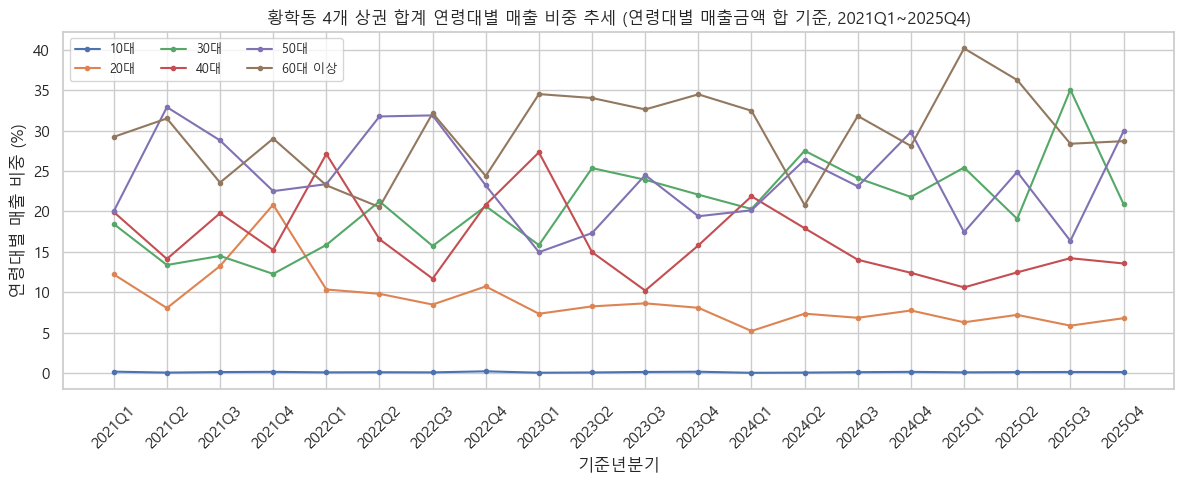

            10대    20대    30대    40대    50대  60대 이상
기준_년분기_코드                                          
20211      0.19  12.22  18.44  19.93  20.01   29.21
20212      0.07   8.05  13.37  14.12  32.89   31.49
20213      0.14  13.25  14.49  19.78  28.78   23.56
20214      0.16  20.83  12.27  15.23  22.51   29.00
20221      0.10  10.34  15.86  27.10  23.37   23.23
20222      0.12   9.81  21.24  16.57  31.74   20.53
20223      0.10   8.48  15.72  11.68  31.87   32.14
20224      0.23  10.72  20.65  20.82  23.21   24.37
20231      0.06   7.35  15.83  27.30  14.96   34.51
20232      0.09   8.26  25.36  14.96  17.32   34.02
20233      0.15   8.63  23.91  10.21  24.49   32.61
20234      0.18   8.08  22.07  15.80  19.40   34.47
20241      0.05   5.21  20.30  21.86  20.14   32.44
20242      0.07   7.35  27.50  17.92  26.38   20.78
20243      0.12   6.85  24.12  14.02  23.09   31.80
20244      0.16   7.75  21.78  12.40  29.82   28.09
20251      0.10   6.29  25.42  10.60  17.43   40.15
20252      0

In [22]:
AGE_AMOUNT_COLS = [
    "연령대_10_매출_금액", "연령대_20_매출_금액", "연령대_30_매출_금액",
    "연령대_40_매출_금액", "연령대_50_매출_금액", "연령대_60_이상_매출_금액",
]
AGE_LABELS = [c.replace("연령대_", "").replace("_매출_금액", "대") for c in AGE_AMOUNT_COLS]
AGE_LABELS = [lbl.replace("60_이상대", "60대 이상") for lbl in AGE_LABELS]

age_quarterly = hwanghak_sales.groupby("기준_년분기_코드")[AGE_AMOUNT_COLS].sum()
age_share = age_quarterly.div(age_quarterly.sum(axis=1), axis=0) * 100
age_share.columns = AGE_LABELS
age_share_plot = age_share.copy()
age_share_plot.index = [QUARTER_LABEL_MAP[q] for q in age_share_plot.index]

fig, ax = plt.subplots(figsize=(12, 5))
for i, col in enumerate(AGE_LABELS):
    ax.plot(age_share_plot.index, age_share_plot[col], marker="o", markersize=3, label=col)
ax.set_title("황학동 4개 상권 합계 연령대별 매출 비중 추세 (연령대별 매출금액 합 기준, 2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("연령대별 매출 비중 (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

print(age_share.round(2))

**해석:** 연령대별 매출금액 합계 기준으로 20대 비중은 2021년 13.66%에서 2025년 6.49%로 오히려 절반
수준으로 줄었고, 30대 비중은 14.48%에서 25.75%로 크게 늘었다. 이미 가장 큰 비중을 차지하던 60대 이상도
28.51%에서 32.94%로 더 커졌다. 즉 "젊은층 유입"이 20대·30대에 균일하게 나타나는 것이 아니라, 20대는
줄고 30대와 60대 이상이 함께 늘어나는 다소 엇갈린 모습이다. 이 결과만으로 "젊은층 유입에 따른 상권
회복"이라는 인과적 결론을 내리지 않는다.

### 2021 vs 2025 연령 구성 비교 및 황학 4개 상권별 차이

,2021_비중(%),2025_비중(%)
10대,0.14,0.13
20대,13.66,6.49
30대,14.48,25.75
40대,17.01,12.82
50대,26.20,21.87
60대 이상,28.51,32.94


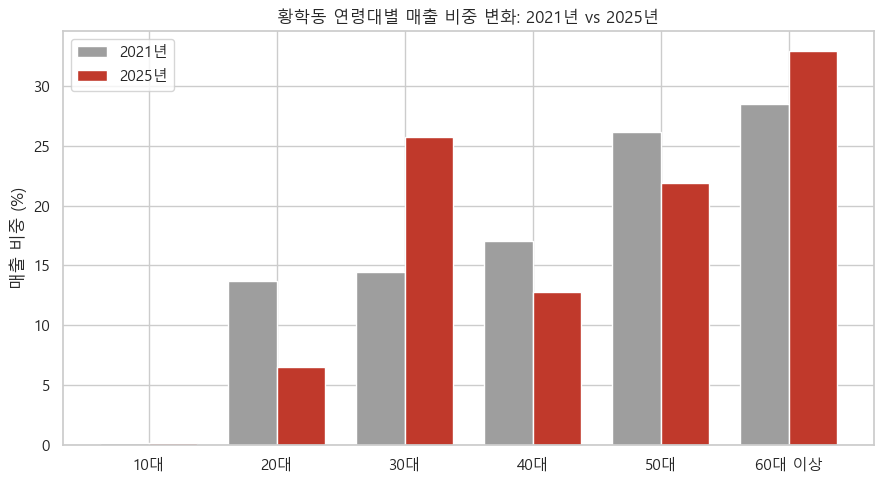

In [23]:
age_2021 = hwanghak_sales[hwanghak_sales["기준_년분기_코드"].between(20211, 20214)][AGE_AMOUNT_COLS].sum()
age_2025 = hwanghak_sales[hwanghak_sales["기준_년분기_코드"].between(20251, 20254)][AGE_AMOUNT_COLS].sum()

age_compare = pd.DataFrame({
    "2021_비중(%)": age_2021 / age_2021.sum() * 100,
    "2025_비중(%)": age_2025 / age_2025.sum() * 100,
})
age_compare.index = AGE_LABELS
display(age_compare.round(2))

x = np.arange(len(AGE_LABELS))
width = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, age_compare["2021_비중(%)"], width, label="2021년", color=SEOUL_COLOR)
ax.bar(x + width / 2, age_compare["2025_비중(%)"], width, label="2025년", color=HWANGHAK_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(AGE_LABELS)
ax.set_ylabel("매출 비중 (%)")
ax.set_title("황학동 연령대별 매출 비중 변화: 2021년 vs 2025년")
ax.legend()
plt.tight_layout()
plt.show()

**해석:** 2021년 대비 2025년 연령 구성 변화를 다시 정리해도 위와 같은 패턴이 유지된다 — 20대(-7.17%p),
40대(-4.19%p), 50대(-4.33%p) 비중이 줄고, 30대(+11.27%p)와 60대 이상(+4.43%p) 비중이 늘었다. 10대
비중은 0.14%->0.13%로 거의 존재감이 없는 수준을 유지한다. 30대와 60대 이상이라는, 방향이 서로 다른
두 연령층의 비중이 함께 커지는 점이 특징적이다.

,,10대,20대,30대,40대,50대,60대 이상
상권_코드,상권_코드_명,,,,,,
3110055,황학동벼룩시장,0.05,3.22,22.35,6.23,27.91,40.24
3110057,황학코아루아파트,0.22,13.34,23.94,17.22,21.78,23.50
3130054,황학동주방가구거리상점가,0.07,6.53,17.92,16.51,26.69,32.28
3130055,"황학시장(서울중앙시장, 신중앙시장)",0.14,9.74,22.97,17.54,21.18,28.43


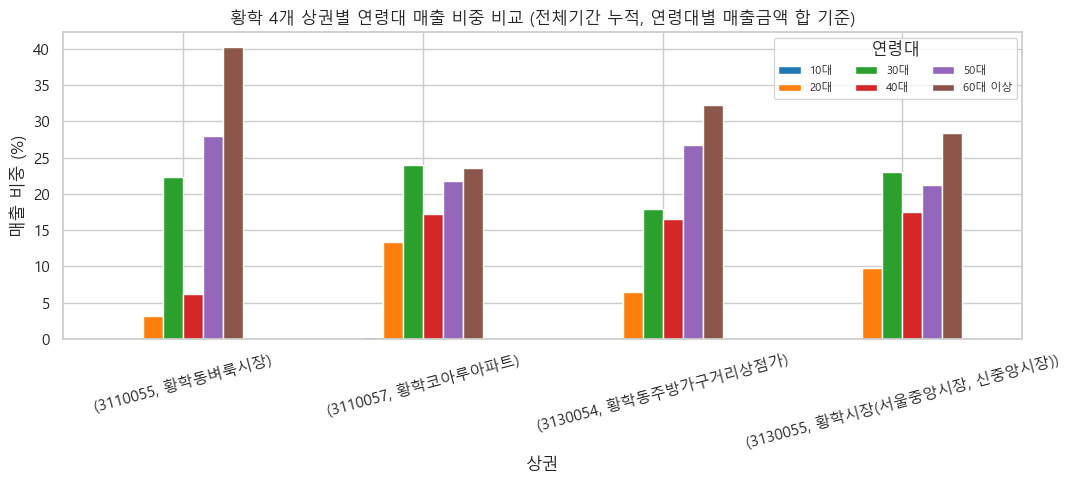

In [24]:
per_area_age = []
for code_ in HWANGHAK_CODES:
    sub = hwanghak_sales[hwanghak_sales["상권_코드"] == code_][AGE_AMOUNT_COLS].sum()
    share = sub / sub.sum() * 100
    row = {"상권_코드": code_, "상권_코드_명": area_names_hwanghak[code_]}
    row.update(dict(zip(AGE_LABELS, share.values)))
    per_area_age.append(row)

per_area_age_df = pd.DataFrame(per_area_age).set_index(["상권_코드", "상권_코드_명"])
display(per_area_age_df.round(2))

per_area_age_df.plot(kind="bar", figsize=(11, 5), color=sns.color_palette("tab10", 6))
plt.title("황학 4개 상권별 연령대 매출 비중 비교 (전체기간 누적, 연령대별 매출금액 합 기준)")
plt.ylabel("매출 비중 (%)")
plt.xlabel("상권")
plt.xticks(rotation=15)
plt.legend(title="연령대", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

**해석:** 상권별 연령 구성도 뚜렷하게 다르다. 황학동벼룩시장은 60대 이상 비중이 40.2%로 압도적으로 높고
20대는 3.2%에 불과해 전통시장·중장년층 중심 성격이 여전히 강하다. 황학코아루아파트는 20대(13.3%)·
30대(23.9%)·40대(17.2%) 비중이 상대적으로 고르게 높아 4개 상권 중 가장 젊은 소비층 구성을 보인다.
황학동주방가구거리상점가와 황학시장은 50~60대 이상 비중이 여전히 높은 편이다. 연령 구성에서도 4개
상권이 하나의 "황학동"으로 묶이기보다 서로 다른 특성을 가진 것으로 보인다.

## 11. 점포 변화 분석

`stores`의 grain은 분기 × 상권 × 업종이므로, 상권/분기 단위로 집계할 때는 `점포_수`, `개업_점포_수`,
`폐업_점포_수`, `프랜차이즈_점포_수`처럼 **합산 가능한 개수(count)** 컬럼만 합산한다. 반대로 `개업_율`,
`폐업_률`은 비율(rate)이므로 업종/상권에 걸쳐 단순 합산하지 않는다.

`02_preprocessing.ipynb`에서 `개업_율` 100 초과 14건, `폐업_률` 100 초과 723건이 서울 전체 기준으로
확인되었다. 공식 산출식을 확인하지 않은 상태이므로 이를 "오류"로 단정하지 않고, 개업/폐업 **점포 수**를
중심으로 분석한다.

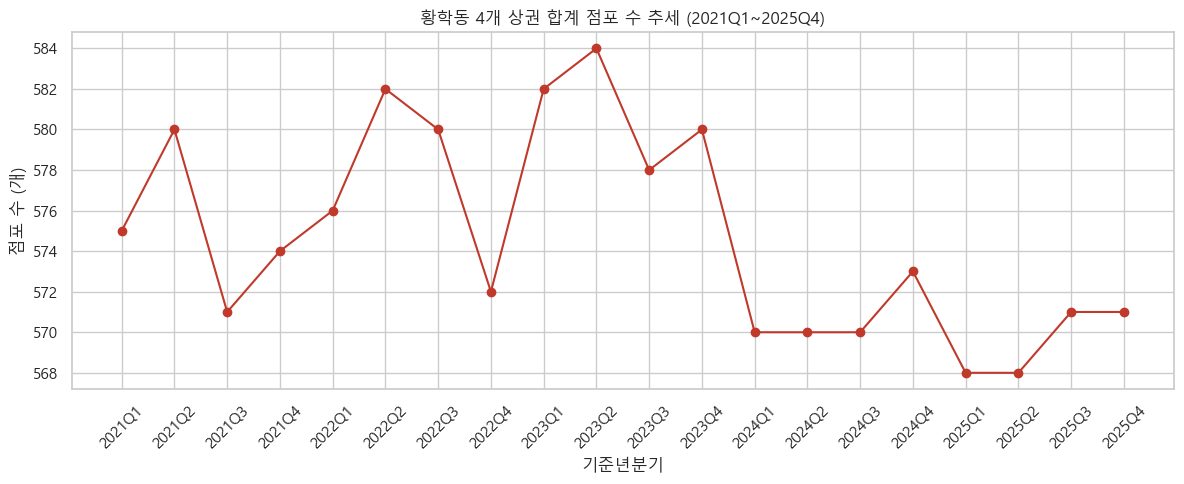

 분기_라벨  점포_수  개업_점포_수  폐업_점포_수  프랜차이즈_점포_수
2021Q1   575        9        9          28
2021Q2   580       15        9          29
2021Q3   571        6       15          29
2021Q4   574       17       12          31
2022Q1   576       12       10          31
2022Q2   582       15       10          30
2022Q3   580       14       16          30
2022Q4   572        9       16          31
2023Q1   582       24       13          32
2023Q2   584       16       13          33
2023Q3   578        8       15          32
2023Q4   580       19       13          36
2024Q1   570       13       21          38
2024Q2   570       18       18          38
2024Q3   570       17       16          39
2024Q4   573       12        9          39
2025Q1   568        8       13          37
2025Q2   568       12       11          37
2025Q3   571       16       15          34
2025Q4   571       10       10          34


In [25]:
STORE_COUNT_COLS = ["점포_수", "개업_점포_수", "폐업_점포_수", "프랜차이즈_점포_수"]

hwanghak_stores_quarterly = hwanghak_stores.groupby("기준_년분기_코드", as_index=False)[STORE_COUNT_COLS].sum()
hwanghak_stores_quarterly = add_quarter_label(hwanghak_stores_quarterly).sort_values("분기_라벨")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hwanghak_stores_quarterly["분기_라벨"], hwanghak_stores_quarterly["점포_수"], marker="o", color=HWANGHAK_COLOR)
ax.set_title("황학동 4개 상권 합계 점포 수 추세 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("점포 수 (개)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(hwanghak_stores_quarterly[["분기_라벨"] + STORE_COUNT_COLS].to_string(index=False))

**해석:** 황학동 4개 상권 합계 점포 수는 2021Q1 575개에서 2025Q4 571개로, 20개 분기 내내 570~584개
사이의 좁은 범위에서 유지된다(연평균 기준 575.0 -> 569.5, -1.0%). 같은 기간 매출은 등락을 반복하며
증가했으므로, 점포 수 자체는 비교적 안정적으로 유지된 채 매출과 매출 구성이 변화하는 패턴과 부합한다.

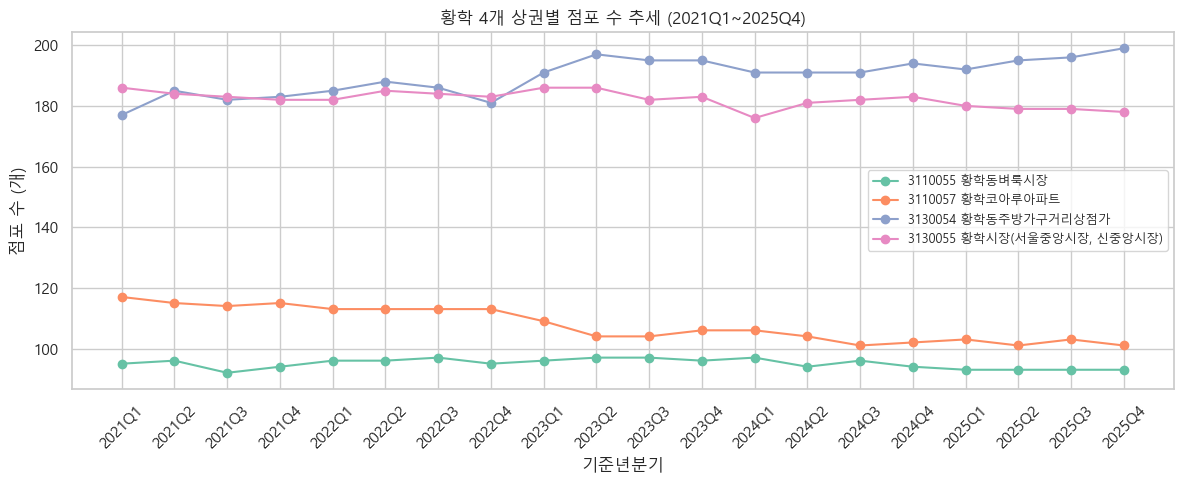

In [26]:
per_area_stores = hwanghak_stores.groupby(["기준_년분기_코드", "상권_코드"], as_index=False)[STORE_COUNT_COLS].sum()
per_area_stores = add_quarter_label(per_area_stores)

fig, ax = plt.subplots(figsize=(12, 5))
for i, code_ in enumerate(HWANGHAK_CODES):
    sub = per_area_stores[per_area_stores["상권_코드"] == code_].sort_values("분기_라벨")
    ax.plot(sub["분기_라벨"], sub["점포_수"], marker="o", color=AREA_PALETTE[i],
            label=f"{code_} {area_names_hwanghak[code_]}")
ax.set_title("황학 4개 상권별 점포 수 추세 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("점포 수 (개)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**해석:** 상권별 점포 수 변화도 엇갈린다 — 황학코아루아파트는 연평균 115.2개(2021)에서 102.0개(2025)로
-11.5% 뚜렷하게 줄었고, 황학시장도 183.8개에서 179.0개로 소폭 감소했다. 반대로 황학동주방가구거리
상점가는 181.8개에서 195.5개로 +7.5% 늘었다(매출은 -15.1% 감소한 상권임에도 점포 수는 오히려 증가).
황학동벼룩시장은 94.2개에서 93.0개로 거의 변화가 없다. 즉 점포 수 증감 방향이 매출 증감 방향과 항상
일치하지 않는다.

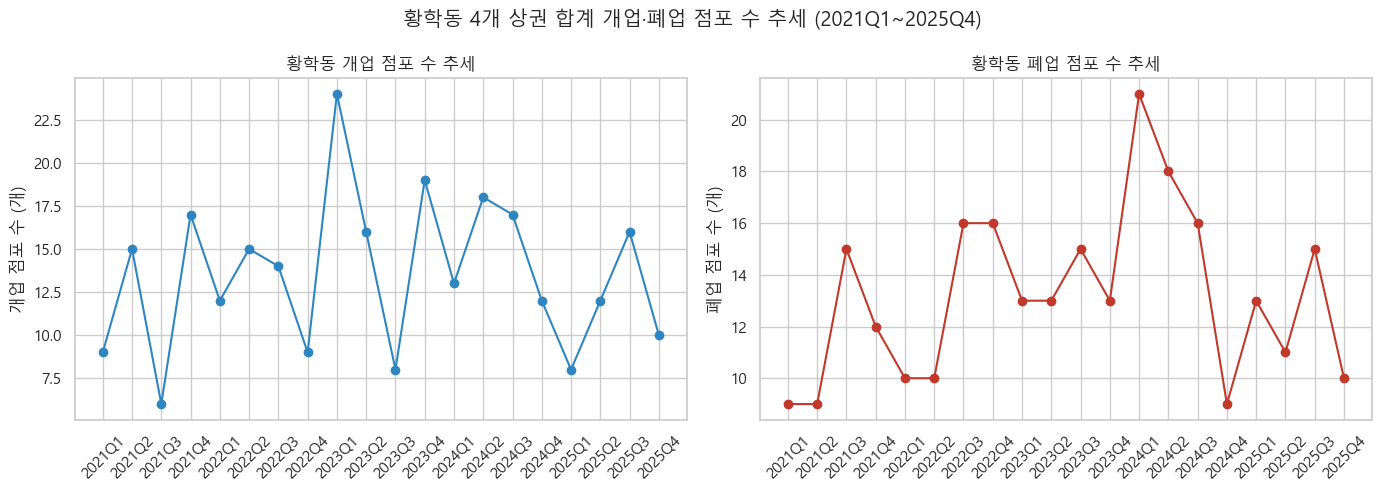

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
axes[0].plot(hwanghak_stores_quarterly["분기_라벨"], hwanghak_stores_quarterly["개업_점포_수"],
             marker="o", color="#2E86C1")
axes[0].set_title("황학동 개업 점포 수 추세")
axes[0].set_ylabel("개업 점포 수 (개)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(hwanghak_stores_quarterly["분기_라벨"], hwanghak_stores_quarterly["폐업_점포_수"],
             marker="o", color="#C0392B")
axes[1].set_title("황학동 폐업 점포 수 추세")
axes[1].set_ylabel("폐업 점포 수 (개)")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("황학동 4개 상권 합계 개업·폐업 점포 수 추세 (2021Q1~2025Q4)")
plt.tight_layout()
plt.show()

**해석:** 황학동 4개 상권 합계 개업 점포 수는 연 47건(2021)에서 46건(2025)으로 거의 같은 수준을 유지한
반면, 폐업 점포 수는 45건에서 49건으로 다소 늘었다(순증가 폭이 줄어드는 방향). 분기별로는 2024Q1에
폐업 점포 수가 21건으로 20개 분기 중 가장 높았고, 이후 다시 낮아지는 등 분기별 변동도 크다.

### 업종별 점포 구조 변화 (매출 TOP 10 업종 기준)

앞서 매출 기준으로 정의한 TOP 10 업종을 대상으로, 2021년 대비 2025년 점포 수가 어떻게 바뀌었는지 확인한다.
이는 이후 "매출 구조 변화와 점포 구조 변화가 함께 나타나는지" 후속 분석의 기초 자료로만 사용한다.

In [28]:
stores_2021 = hwanghak_stores[hwanghak_stores["기준_년분기_코드"].between(20211, 20214)]
stores_2025 = hwanghak_stores[hwanghak_stores["기준_년분기_코드"].between(20251, 20254)]

# 점포_수는 분기 시점의 스톡(재고성) 지표이므로, 연도 내 4개 분기 평균으로 연간 대표값을 만든다.
store_count_2021 = (
    stores_2021.groupby(["기준_년분기_코드", "서비스_업종_코드_명"])["점포_수"].sum()
    .groupby("서비스_업종_코드_명").mean()
)
store_count_2025 = (
    stores_2025.groupby(["기준_년분기_코드", "서비스_업종_코드_명"])["점포_수"].sum()
    .groupby("서비스_업종_코드_명").mean()
)

store_change_top = pd.DataFrame({
    "2021_평균_점포수": store_count_2021,
    "2025_평균_점포수": store_count_2025,
}).reindex(top_categories_overall).fillna(0)
store_change_top["점포수_변화"] = store_change_top["2025_평균_점포수"] - store_change_top["2021_평균_점포수"]

display(store_change_top.round(1))

print("[참고: 개업_율/폐업_률이 100을 초과하는 사례가 황학 4개 상권 stores 데이터에 존재하는지 확인]")
rate_over_100 = hwanghak_stores[(hwanghak_stores["개업_율"] > 100) | (hwanghak_stores["폐업_률"] > 100)]
print("개업_율 또는 폐업_률이 100을 초과하는 행 수:", len(rate_over_100), "/", len(hwanghak_stores))
if len(rate_over_100) > 0:
    display(rate_over_100[["기준_년분기_코드", "상권_코드", "서비스_업종_코드_명", "개업_율", "폐업_률",
                            "점포_수", "개업_점포_수", "폐업_점포_수"]].head(10))

,2021_평균_점포수,2025_평균_점포수,점포수_변화
서비스_업종_코드_명,,,
가구,31.8,32.5,0.8
한식음식점,53.5,55.0,1.5
육류판매,36.2,27.5,-8.8
슈퍼마켓,17.0,15.8,-1.2
치과의원,5.0,4.2,-0.8
전자상거래업,25.8,20.0,-5.8
일반의류,43.8,43.8,0.0
가전제품,11.8,11.5,-0.2
반찬가게,20.2,17.2,-3.0


[참고: 개업_율/폐업_률이 100을 초과하는 사례가 황학 4개 상권 stores 데이터에 존재하는지 확인]
개업_율 또는 폐업_률이 100을 초과하는 행 수: 0 / 3000


**해석:** 가구 업종은 점포 수가 연평균 31.8개(2021)->32.5개(2025)로 거의 그대로 유지되었음에도 매출은
-26.9% 줄어, 업종 내 점포당 평균 매출이 약해지고 있을 가능성을 시사한다(원인은 확정할 수 없음). 반대로
전자상거래업은 점포 수가 25.8개->20.0개로 줄었는데 매출은 오히려 크게 늘어(+393%), 소수 사업자 중심으로
성장했을 가능성이 있다. 한식음식점은 점포 수(53.5->55.0)와 매출(+58.8%) 모두 증가해 방향이 일치한다.
한편 황학 4개 상권 stores 데이터 3,000행 중 개업_율·폐업_률이 100을 초과하는 행은 0건으로, `02`에서
확인된 서울 전체 기준 100% 초과 사례(개업_율 14건, 폐업_률 723건)는 황학동 자체에서는 나타나지 않는
것으로 확인된다.

## 12. 생활인구 추세 분석

`population`은 분기 × 상권 grain이므로 업종 단위 집계가 필요 없다. 서울 전체와 비교할 때도 앞서와 동일하게
"상권 1개당 평균" 또는 index 방식을 사용하고, 서울 total과 황학 total을 그대로 비교하지 않는다.

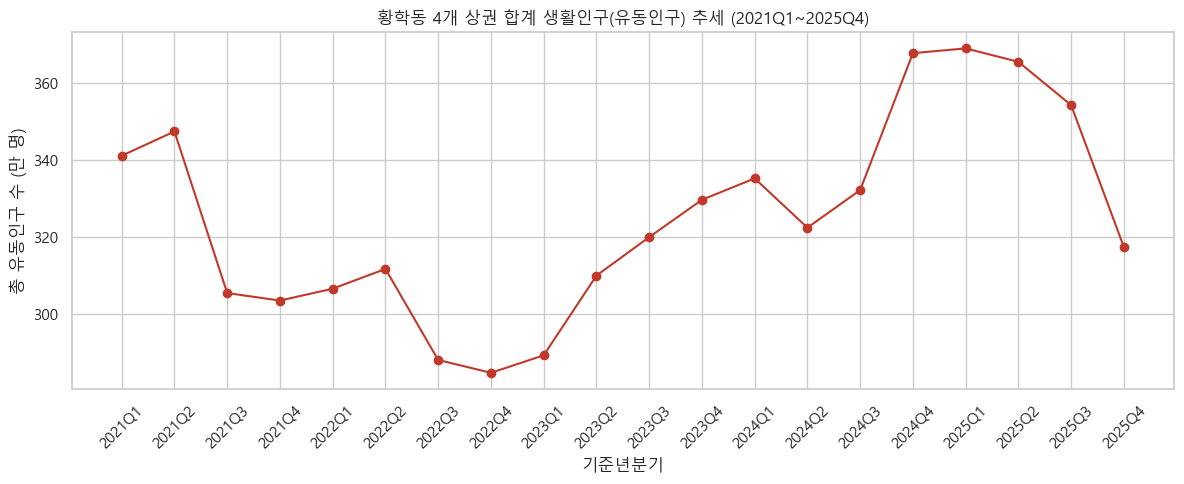

 분기_라벨  총_유동인구_수
2021Q1   3411292
2021Q2   3474561
2021Q3   3053551
2021Q4   3034051
2022Q1   3064941
2022Q2   3116467
2022Q3   2879280
2022Q4   2845881
2023Q1   2891418
2023Q2   3098954
2023Q3   3199290
2023Q4   3296464
2024Q1   3352309
2024Q2   3223870
2024Q3   3321810
2024Q4   3678469
2025Q1   3690899
2025Q2   3655907
2025Q3   3543096
2025Q4   3173317


In [29]:
hwanghak_population_quarterly = hwanghak_population.groupby("기준_년분기_코드", as_index=False)["총_유동인구_수"].sum()
hwanghak_population_quarterly = add_quarter_label(hwanghak_population_quarterly).sort_values("분기_라벨")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hwanghak_population_quarterly["분기_라벨"], hwanghak_population_quarterly["총_유동인구_수"] / 1e4,
        marker="o", color=HWANGHAK_COLOR)
ax.set_title("황학동 4개 상권 합계 생활인구(유동인구) 추세 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("총 유동인구 수 (만 명)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(hwanghak_population_quarterly[["분기_라벨", "총_유동인구_수"]].to_string(index=False))

**해석:** 황학동 4개 상권 합계 유동인구는 2021Q1 약 341만명에서 등락을 거치며 2022Q4 약 285만명까지
줄었다가(저점), 이후 회복해 2025Q1 약 369만명(최고점)까지 늘었고, 다시 2025Q4에는 약 317만명으로
줄었다. 2021년과 2025년의 분기 평균 유동인구를 비교하면 +8.4% 증가한 것으로 나타난다(생활인구는 매출과
달리 4개 분기 값을 그대로 합산하는 것이 원본 데이터의 공식 집계 기준상 타당한지 이 프로젝트의 데이터만으로는
확인할 수 없어, 이 노트북에서는 합계 대신 분기 평균을 대표값으로 사용한다 — 자세한 내용은 20절 참고). 다만
2025년 내부에서만 보면 최근 분기로 갈수록 다시 감소하는 모습이 함께 나타난다.

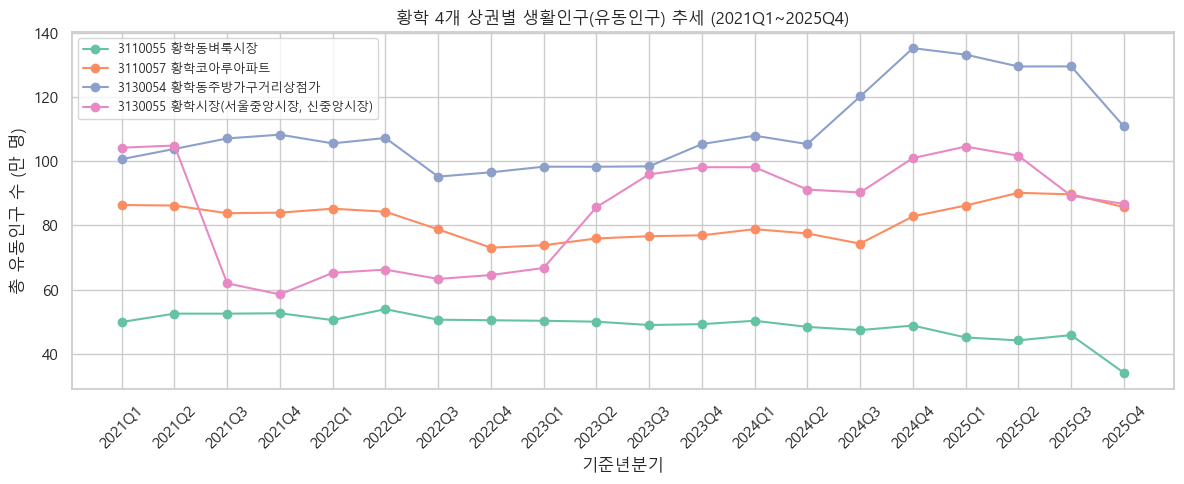

In [30]:
per_area_population = hwanghak_population.groupby(["기준_년분기_코드", "상권_코드"], as_index=False)["총_유동인구_수"].sum()
per_area_population = add_quarter_label(per_area_population)

fig, ax = plt.subplots(figsize=(12, 5))
for i, code_ in enumerate(HWANGHAK_CODES):
    sub = per_area_population[per_area_population["상권_코드"] == code_].sort_values("분기_라벨")
    ax.plot(sub["분기_라벨"], sub["총_유동인구_수"] / 1e4, marker="o", color=AREA_PALETTE[i],
            label=f"{code_} {area_names_hwanghak[code_]}")
ax.set_title("황학 4개 상권별 생활인구(유동인구) 추세 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("총 유동인구 수 (만 명)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**해석:** 상권별 유동인구 변화도 엇갈린다 — 황학동주방가구거리상점가(+19.8%)와 황학시장(+16.0%)은
뚜렷하게 늘었고 황학코아루아파트는 소폭 증가(+3.4%)한 반면, 황학동벼룩시장은 -18.5%로 유일하게 줄었다.
특히 벼룩시장은 매출은 4개 상권 중 가장 크게 늘었으면서도(+117.7%) 유동인구는 오히려 줄어든 상권으로,
유동인구와 매출이 반대 방향으로 움직이는 대표적인 사례다.

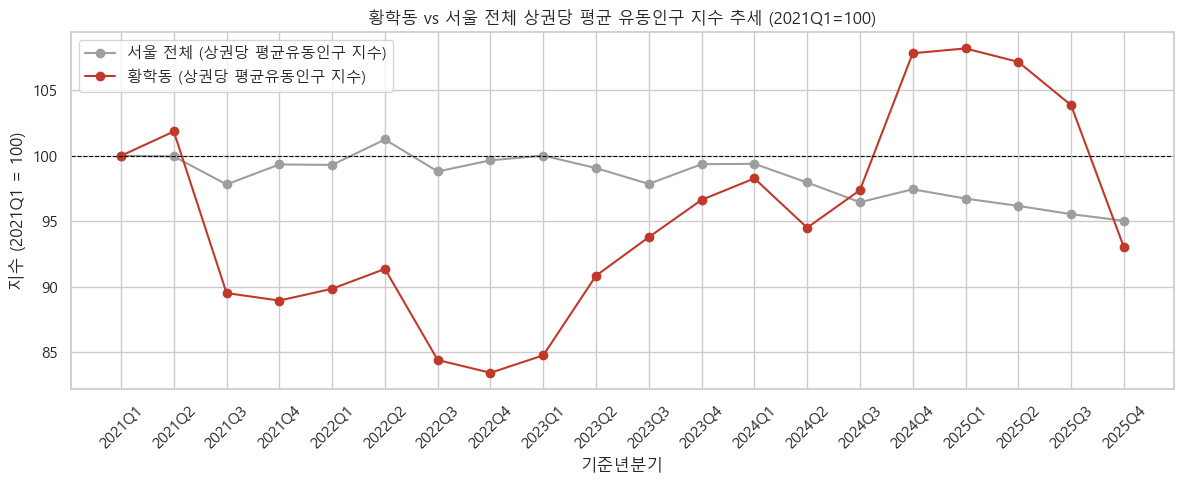

 분기_라벨      서울_지수      황학_지수
2021Q1 100.000000 100.000000
2021Q2  99.953557 101.854693
2021Q3  97.811885  89.513035
2021Q4  99.336678  88.941404
2022Q1  99.303218  89.846926
2022Q2 101.243456  91.357380
2022Q3  98.801159  84.404384
2022Q4  99.653215  83.425312
2023Q1 100.014758  84.760202
2023Q2  99.058746  90.843997
2023Q3  97.850857  93.785287
2023Q4  99.358225  96.633885
2024Q1  99.384855  98.270948
2024Q2  97.960815  94.505835
2024Q3  96.453674  97.376888
2024Q4  97.440855 107.832135
2025Q1  96.731527 108.196513
2025Q2  96.172765 107.170744
2025Q3  95.542365 103.863756
2025Q4  95.040991  93.023904


In [31]:
seoul_area_population = population.groupby(["기준_년분기_코드", "상권_코드"], as_index=False)["총_유동인구_수"].sum()
seoul_avg_pop_per_area = seoul_area_population.groupby("기준_년분기_코드")["총_유동인구_수"].mean().rename("서울_상권당_평균유동인구")
hwanghak_avg_pop_per_area = per_area_population.groupby("기준_년분기_코드")["총_유동인구_수"].mean().rename("황학_상권당_평균유동인구")

pop_compare = pd.concat([seoul_avg_pop_per_area, hwanghak_avg_pop_per_area], axis=1).reset_index()
pop_compare = add_quarter_label(pop_compare).sort_values("분기_라벨")

base_seoul_pop = pop_compare.loc[pop_compare["기준_년분기_코드"] == base_q, "서울_상권당_평균유동인구"].iloc[0]
base_hwanghak_pop = pop_compare.loc[pop_compare["기준_년분기_코드"] == base_q, "황학_상권당_평균유동인구"].iloc[0]
pop_compare["서울_지수"] = pop_compare["서울_상권당_평균유동인구"] / base_seoul_pop * 100
pop_compare["황학_지수"] = pop_compare["황학_상권당_평균유동인구"] / base_hwanghak_pop * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pop_compare["분기_라벨"], pop_compare["서울_지수"], marker="o", color=SEOUL_COLOR, label="서울 전체 (상권당 평균유동인구 지수)")
ax.plot(pop_compare["분기_라벨"], pop_compare["황학_지수"], marker="o", color=HWANGHAK_COLOR, label="황학동 (상권당 평균유동인구 지수)")
ax.axhline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_title("황학동 vs 서울 전체 상권당 평균 유동인구 지수 추세 (2021Q1=100)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("지수 (2021Q1 = 100)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print(pop_compare[["분기_라벨", "서울_지수", "황학_지수"]].to_string(index=False))

**해석:** 지수(2021Q1=100) 기준으로 2025Q4에 서울 전체는 95.0, 황학동은 93.0으로 두 그룹 모두 5년
전보다 소폭 낮은 수준에서 마무리된다(방향은 같음). 다만 그 경로에서 황학동은 2022~2023년 중 83~90 부근까지
내려갔다가 2024년 이후 100 안팎까지 회복하는 등 서울 전체(대체로 95~101 사이에서 완만하게 움직임)보다
훨씬 큰 폭의 변동을 보였다. 유동인구에서도 매출과 유사하게, 장기 방향은 서울과 크게 다르지 않지만
변동성은 황학동이 더 크다는 패턴이 반복된다.

## 13. 생활인구 연령 구조 분석

`02_preprocessing.ipynb`에서 population의 연령대별/성별 유동인구 합계도 `총_유동인구_수`와 완전히 일치하지
않는 행이 존재했다(완전 일치 비율 30~50% 수준, 다만 절대 차이의 중앙값은 0~1명, 최대 절대 차이도 5명 이내로
작았다). sales의 연령대 매출과 같은 이유로, 여기서도 안전하게 **연령대별 유동인구 6개 컬럼의 합계**를
분모로 사용해 구성비를 계산한다 (다만 population은 절대 차이 자체가 매우 작아 sales만큼 영향이 크지는 않다).

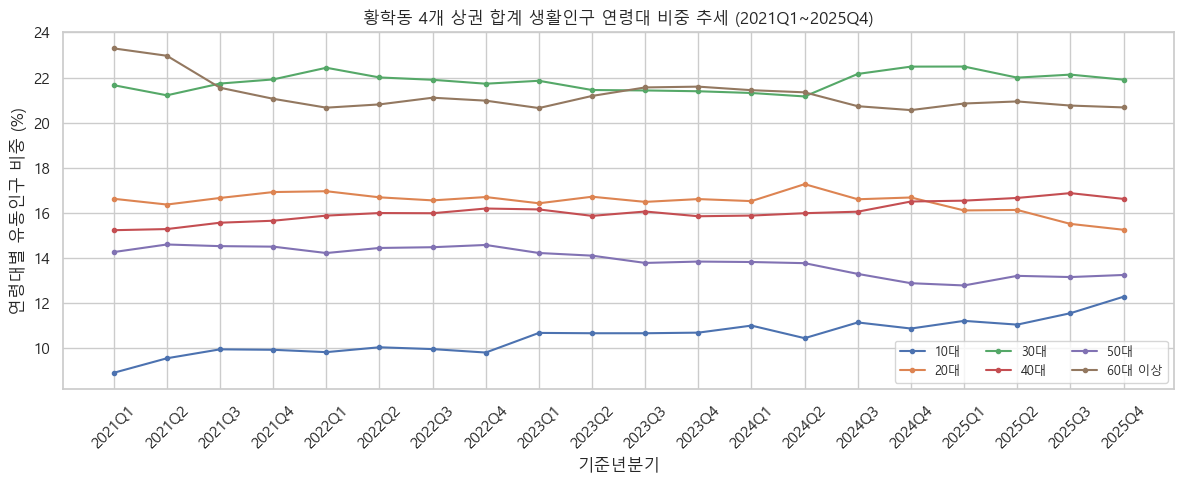

,2021_비중(%),2025_비중(%)
10대,9.57,11.50
20대,16.64,15.77
30대,21.62,22.14
40대,15.43,16.68
50대,14.47,13.10
60대 이상,22.27,20.81


In [32]:
AGE_POP_COLS = [
    "연령대_10_유동인구_수", "연령대_20_유동인구_수", "연령대_30_유동인구_수",
    "연령대_40_유동인구_수", "연령대_50_유동인구_수", "연령대_60_이상_유동인구_수",
]

age_pop_quarterly = hwanghak_population.groupby("기준_년분기_코드")[AGE_POP_COLS].sum()
age_pop_share = age_pop_quarterly.div(age_pop_quarterly.sum(axis=1), axis=0) * 100
age_pop_share.columns = AGE_LABELS
age_pop_share_plot = age_pop_share.copy()
age_pop_share_plot.index = [QUARTER_LABEL_MAP[q] for q in age_pop_share_plot.index]

fig, ax = plt.subplots(figsize=(12, 5))
for col in AGE_LABELS:
    ax.plot(age_pop_share_plot.index, age_pop_share_plot[col], marker="o", markersize=3, label=col)
ax.set_title("황학동 4개 상권 합계 생활인구 연령대 비중 추세 (2021Q1~2025Q4)")
ax.set_xlabel("기준년분기")
ax.set_ylabel("연령대별 유동인구 비중 (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

age_pop_2021 = hwanghak_population[hwanghak_population["기준_년분기_코드"].between(20211, 20214)][AGE_POP_COLS].sum()
age_pop_2025 = hwanghak_population[hwanghak_population["기준_년분기_코드"].between(20251, 20254)][AGE_POP_COLS].sum()
age_pop_compare = pd.DataFrame({
    "2021_비중(%)": age_pop_2021 / age_pop_2021.sum() * 100,
    "2025_비중(%)": age_pop_2025 / age_pop_2025.sum() * 100,
})
age_pop_compare.index = AGE_LABELS
display(age_pop_compare.round(2))

**해석:** 생활인구 연령 구성 변화는 매출 연령 구성 변화와 다른 방향을 보인다. 유동인구 기준으로는
60대 이상 비중이 22.27%->20.81%로 오히려 줄고 10대(+1.93%p)·40대(+1.25%p) 비중이 늘어난 반면,
매출 기준으로는 60대 이상 비중이 28.51%->32.94%로 늘고 20대 비중이 크게 줄었다. 즉 "방문객(유동인구)
연령 구성"과 "소비(매출) 연령 구성"이 같은 방향으로 움직이지 않는다 — 유동인구 중 젊은 연령대가 소폭
늘어난 것이 매출의 젊은 연령대 비중 증가로 곧바로 이어지지는 않는 것으로 보인다.

,,10대,20대,30대,40대,50대,60대 이상
상권_코드,상권_코드_명,,,,,,
3110055,황학동벼룩시장,9.36,14.05,23.50,17.83,13.32,21.94
3110057,황학코아루아파트,12.36,18.83,21.44,15.16,13.58,18.63
3130054,황학동주방가구거리상점가,10.51,15.73,23.50,16.94,12.80,20.52
3130055,"황학시장(서울중앙시장, 신중앙시장)",9.50,16.60,19.07,14.76,15.79,24.29


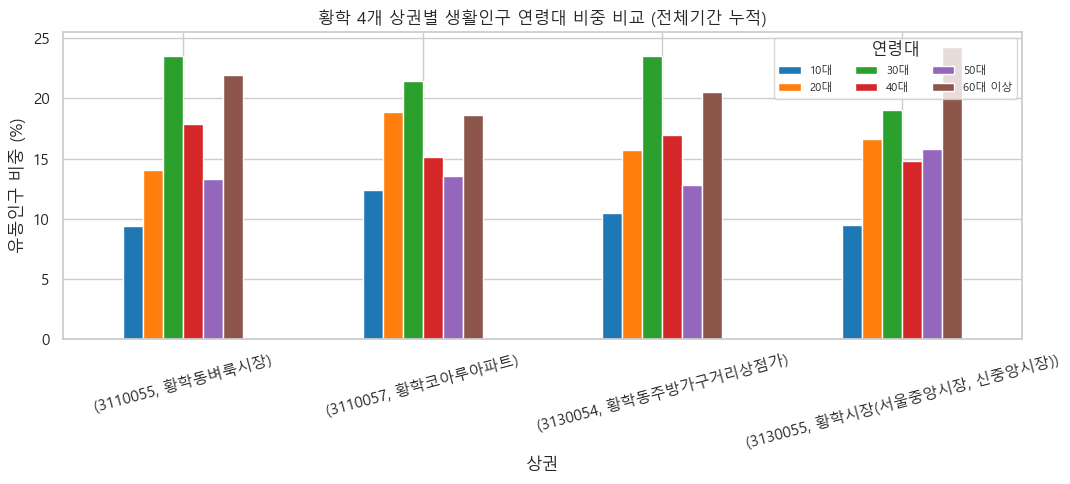

In [33]:
per_area_age_pop = []
for code_ in HWANGHAK_CODES:
    sub = hwanghak_population[hwanghak_population["상권_코드"] == code_][AGE_POP_COLS].sum()
    share = sub / sub.sum() * 100
    row = {"상권_코드": code_, "상권_코드_명": area_names_hwanghak[code_]}
    row.update(dict(zip(AGE_LABELS, share.values)))
    per_area_age_pop.append(row)

per_area_age_pop_df = pd.DataFrame(per_area_age_pop).set_index(["상권_코드", "상권_코드_명"])
display(per_area_age_pop_df.round(2))

per_area_age_pop_df.plot(kind="bar", figsize=(11, 5), color=sns.color_palette("tab10", 6))
plt.title("황학 4개 상권별 생활인구 연령대 비중 비교 (전체기간 누적)")
plt.ylabel("유동인구 비중 (%)")
plt.xlabel("상권")
plt.xticks(rotation=15)
plt.legend(title="연령대", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

**해석:** 유동인구 연령 구성도 상권별로 다르다. 황학코아루아파트는 10~30대 합산 비중(52.6%)이 가장 높고
60대 이상 비중(18.6%)이 가장 낮은 반면, 황학시장은 60대 이상 비중(24.3%)이 가장 높다. 매출 연령 구성에서
확인된 "코아루아파트가 가장 젊은 소비층 구성"이라는 패턴이 유동인구 연령 구성에서도 유사하게 나타나,
이 상권은 방문객 구성 자체가 상대적으로 젊다는 근거가 함께 확인된다.

## 14. 생활인구 시간대 구조 분석

`population`의 시간대별 유동인구 컬럼(`시간대_00_06_유동인구_수` 등, sales와 달리 물결표 없이 밑줄로 구분됨)을
사용한다. sales의 시간대 매출 분석과 비교할 수 있도록 heatmap 구성을 동일하게 맞춘다.

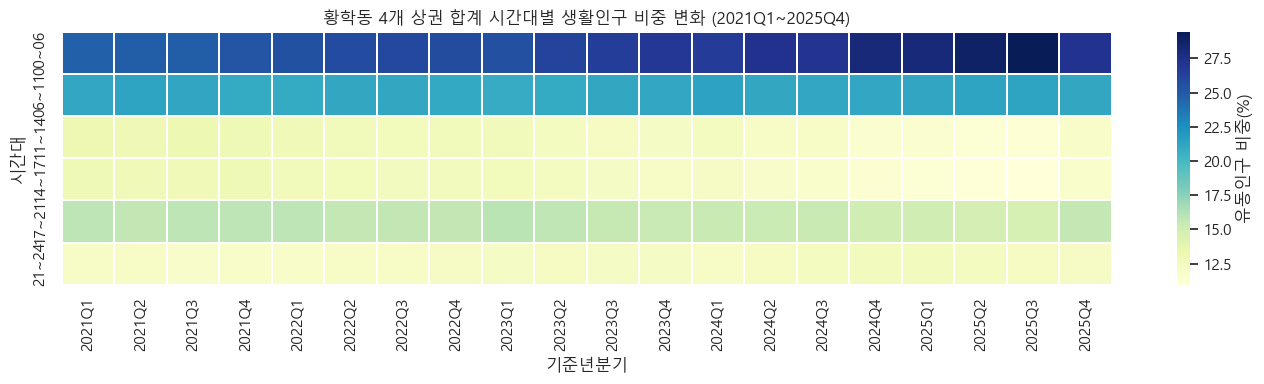

In [34]:
TIME_POP_COLS = [
    "시간대_00_06_유동인구_수", "시간대_06_11_유동인구_수", "시간대_11_14_유동인구_수",
    "시간대_14_17_유동인구_수", "시간대_17_21_유동인구_수", "시간대_21_24_유동인구_수",
]
TIME_POP_LABELS = [c.replace("시간대_", "").replace("_유동인구_수", "").replace("_", "~") for c in TIME_POP_COLS]

time_pop_quarterly = hwanghak_population.groupby("기준_년분기_코드")[TIME_POP_COLS].sum()
time_pop_share = time_pop_quarterly.div(time_pop_quarterly.sum(axis=1), axis=0) * 100
time_pop_share.columns = TIME_POP_LABELS
time_pop_share.index = [QUARTER_LABEL_MAP[q] for q in time_pop_share.index]
time_pop_share_T = time_pop_share.T

plt.figure(figsize=(14, 4))
sns.heatmap(time_pop_share_T, cmap="YlGnBu", cbar_kws={"label": "유동인구 비중(%)"}, linewidths=0.3)
plt.title("황학동 4개 상권 합계 시간대별 생활인구 비중 변화 (2021Q1~2025Q4)")
plt.xlabel("기준년분기")
plt.ylabel("시간대")
plt.tight_layout()
plt.show()

**해석:** 생활인구 시간대 비중은 00~06시가 두 해 모두 가장 크고(2021년 24.91% -> 2025년 28.47%로 오히려
더 늘었다), 11~14시(13.11%->11.56%)·14~17시(12.96%->11.31%)는 줄었다. 다만 서울시 생활인구 통계는
상주인구·근무인구·방문인구를 종합적으로 추정하는 방식이어서, 심야~새벽 시간대의 높은 비중은 상주인구
기반값이 많이 반영된 결과일 가능성이 있다(공식 산출 방식을 확정할 근거는 없음). 따라서 이 시간대 비중을
sales의 매출 시간대 비중과 동일한 의미로 곧바로 비교하지 않도록 주의해야 하며, "낮 시간대 비중이 줄어드는
방향"만 매출 쪽 관찰과 조심스럽게 함께 참고한다.

## 15. 매출·점포·생활인구 통합 탐색

`sales`/`stores`는 grain이 `분기 × 상권 × 업종`이고 `population`은 `분기 × 상권`이므로, 원본 데이터를
그대로 거대한 DataFrame으로 merge하지 않는다. 먼저 각 데이터를 `기준_년분기_코드 × 상권_코드` grain으로
필요한 값만 집계한 뒤에만 병합한다.

`stores`는 (분기, 상권) 조합이 20개 분기 × 1,650개 상권 = 33,000건으로 서울 전체 상권에 대해 완전한
격자(dense grid)를 이루는 반면, `sales`는 일부 (분기, 상권)에 매출 실적이 없어 더 적고(31,415건),
`population`도 일부 상권 커버리지 차이가 있다(`02`에서 확인된 미매칭 사실). 따라서 `stores` 집계를
기준(좌측)으로 두고 `sales`/`population`을 **left join**하여, 병합 이후 결측(누락)이 얼마나 생기는지
명시적으로 확인한다. 이 요약 DataFrame은 이 노트북 안에서 탐색용으로만 사용하고 `data/processed`에
저장하지 않는다.

In [35]:
area_quarter_sales = sales.groupby(["기준_년분기_코드", "상권_코드"], as_index=False).agg(
    총매출금액=("당월_매출_금액", "sum"),
    총매출건수=("당월_매출_건수", "sum"),
)

area_quarter_stores = stores.groupby(["기준_년분기_코드", "상권_코드"], as_index=False).agg(
    점포수=("점포_수", "sum"),
    개업점포수=("개업_점포_수", "sum"),
    폐업점포수=("폐업_점포_수", "sum"),
    프랜차이즈점포수=("프랜차이즈_점포_수", "sum"),
)

area_quarter_population = population[["기준_년분기_코드", "상권_코드", "총_유동인구_수"]].drop_duplicates()

print("area_quarter_sales grain 행 수:", len(area_quarter_sales))
print("area_quarter_stores grain 행 수:", len(area_quarter_stores))
print("area_quarter_population grain 행 수:", len(area_quarter_population))

area_quarter_summary = area_quarter_stores.merge(
    area_quarter_sales, on=["기준_년분기_코드", "상권_코드"], how="left"
).merge(
    area_quarter_population, on=["기준_년분기_코드", "상권_코드"], how="left"
)

print("\nmerge 이후 area_quarter_summary 행 수:", len(area_quarter_summary))
print("(stores 기준 33,000행 그대로 유지되어야 함 — outer가 아닌 stores 기준 left join이기 때문)")

na_report = area_quarter_summary[["총매출금액", "총매출건수", "총_유동인구_수"]].isna().sum()
print("\n병합 후 결측치(매칭되지 않은 (분기,상권)) 수:")
print(na_report)
print("\n->", "매출/유동인구 값이 모두 존재하는 행 수:",
      int(area_quarter_summary[["총매출금액", "총_유동인구_수"]].dropna().shape[0]), "/", len(area_quarter_summary))

area_quarter_sales grain 행 수: 31415
area_quarter_stores grain 행 수: 33000
area_quarter_population grain 행 수: 32984

merge 이후 area_quarter_summary 행 수: 33000
(stores 기준 33,000행 그대로 유지되어야 함 — outer가 아닌 stores 기준 left join이기 때문)

병합 후 결측치(매칭되지 않은 (분기,상권)) 수:
총매출금액       1585
총매출건수       1585
총_유동인구_수      16
dtype: int64

-> 매출/유동인구 값이 모두 존재하는 행 수: 31399 / 33000


**해석:** `stores` 기준 33,000행 중 매출이 매칭되지 않는 행이 1,585건(약 4.8%), 유동인구가 매칭되지
않는 행이 16건(약 0.05%) 확인되었으며, 이는 `02_preprocessing.ipynb`에서 이미 확인한 수록 범위 차이
(sales에만 있는 key 16건, population에만 있는 key 1,585건)와 정확히 일치한다. 즉 이번 병합 과정에서
새로 발생한 문제가 아니라 기존에 알려진 데이터 수록 범위 차이이며, 결측 행을 임의로 0으로 채우지 않고
그대로 남겨둔다. 매출·유동인구 값이 모두 존재하는 행은 31,399건(전체의 약 95.1%)으로, 이후 관계 탐색은
이 31,399건을 기준으로 진행한다.

## 16. 매출과 생활인구 관계 탐색

`area_quarter_summary`에서 매출과 유동인구가 **모두 존재하는 행만 명시적으로 사용**하여 관계를 탐색한다.
서울 전체 상권(회색 점) 위에 황학 4개 상권(색상 점)을 겹쳐 그려 상대적 위치를 확인한다. 상관계수는
참고용 기술통계로만 제시하며, 인과관계를 주장하지 않는다.

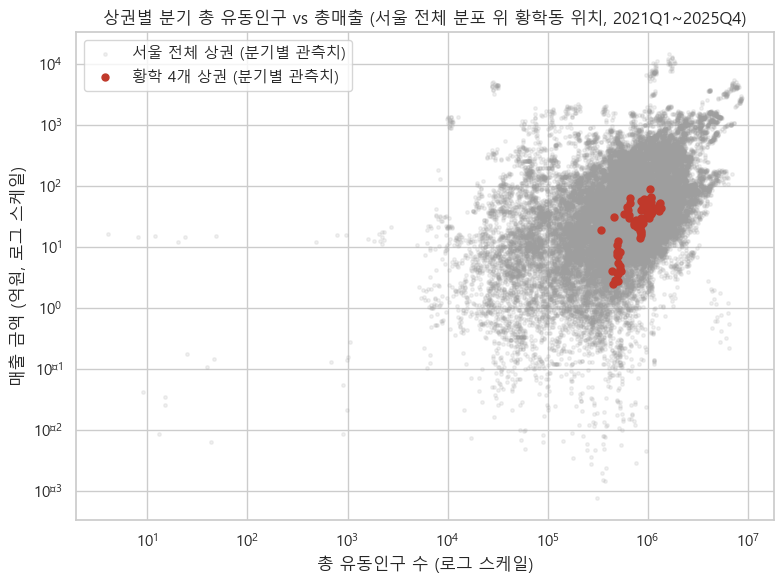

서울 전체 상권-분기 관측치 기준 유동인구-매출 상관계수(참고용, 인과관계 아님): 0.313


In [36]:
level_df = area_quarter_summary.dropna(subset=["총매출금액", "총_유동인구_수"]).copy()
level_df["황학여부"] = level_df["상권_코드"].isin(HWANGHAK_CODES)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(level_df.loc[~level_df["황학여부"], "총_유동인구_수"],
           level_df.loc[~level_df["황학여부"], "총매출금액"] / 1e8,
           s=6, alpha=0.15, color=SEOUL_COLOR, label="서울 전체 상권 (분기별 관측치)")
ax.scatter(level_df.loc[level_df["황학여부"], "총_유동인구_수"],
           level_df.loc[level_df["황학여부"], "총매출금액"] / 1e8,
           s=25, color=HWANGHAK_COLOR, label="황학 4개 상권 (분기별 관측치)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("총 유동인구 수 (로그 스케일)")
ax.set_ylabel("매출 금액 (억원, 로그 스케일)")
ax.set_title("상권별 분기 총 유동인구 vs 총매출 (서울 전체 분포 위 황학동 위치, 2021Q1~2025Q4)")
ax.legend()
plt.tight_layout()
plt.show()

corr = level_df["총_유동인구_수"].corr(level_df["총매출금액"])
print(f"서울 전체 상권-분기 관측치 기준 유동인구-매출 상관계수(참고용, 인과관계 아님): {corr:.3f}")

**해석:** 서울 전체 상권-분기 관측치 기준 유동인구-매출 상관계수는 0.313으로 약한 양의 상관관계에
그친다. 로그-로그 산점도에서도 서울 전체 분포가 넓게 퍼져 있어, 유동인구가 많다고 해서 매출이 반드시
크지는 않다는 것을 알 수 있다. 황학 4개 상권은 이 넓은 분포의 중간 지점 부근에 위치하며 극단적인 위치에
있지 않다. 상관계수가 낮다는 사실 자체를 인과관계의 근거로 사용하지 않는다.

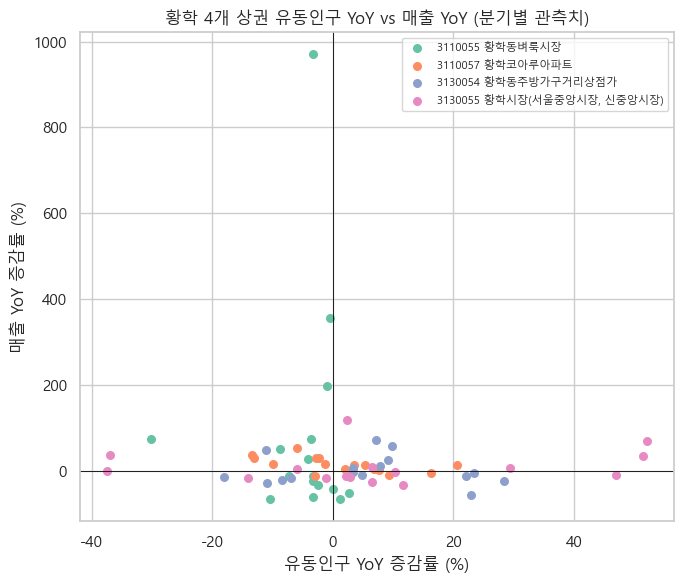

In [37]:
# 황학동에 한정해, 유동인구 변화(YoY)와 매출 변화(YoY)가 함께 나타나는지 탐색한다.
hwanghak_change = area_quarter_summary[area_quarter_summary["상권_코드"].isin(HWANGHAK_CODES)].copy()
hwanghak_change = hwanghak_change.sort_values(["상권_코드", "기준_년분기_코드"])

hwanghak_change["매출_YoY(%)"] = hwanghak_change.groupby("상권_코드")["총매출금액"].pct_change(periods=4) * 100
hwanghak_change["유동인구_YoY(%)"] = hwanghak_change.groupby("상권_코드")["총_유동인구_수"].pct_change(periods=4) * 100
hwanghak_change_valid = hwanghak_change.dropna(subset=["매출_YoY(%)", "유동인구_YoY(%)"])

fig, ax = plt.subplots(figsize=(7, 6))
for i, code_ in enumerate(HWANGHAK_CODES):
    sub = hwanghak_change_valid[hwanghak_change_valid["상권_코드"] == code_]
    ax.scatter(sub["유동인구_YoY(%)"], sub["매출_YoY(%)"], color=AREA_PALETTE[i],
               label=f"{code_} {area_names_hwanghak[code_]}", s=30)
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("유동인구 YoY 증감률 (%)")
ax.set_ylabel("매출 YoY 증감률 (%)")
ax.set_title("황학 4개 상권 유동인구 YoY vs 매출 YoY (분기별 관측치)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**해석:** 4개 상권의 유동인구 YoY와 매출 YoY를 함께 놓고 보면 네 사분면 모두에 관측치가 분포한다.
특히 황학동주방가구거리상점가는 유동인구가 늘어난 분기에도 매출이 줄어드는 사분면(유동인구 YoY > 0,
매출 YoY < 0)에 위치하는 관측치가 상대적으로 자주 나타나며, 이는 앞서 연간 비교에서 확인한 "유동인구
+19.8%, 매출 -15.1%"라는 조합과 같은 방향이다. "유동인구가 늘면 매출도 는다"는 단순한 관계로 황학동
전체를 설명하기는 어렵다는 것을 보여주는 사례이며, 인과관계로 해석하지 않는다.

## 17. 매출과 점포 관계 탐색

동일한 방식으로 점포 수·폐업 점포 수와 매출의 관계를 탐색한다. 역시 동시에 나타나는 패턴만 확인하고
인과관계로 해석하지 않는다.

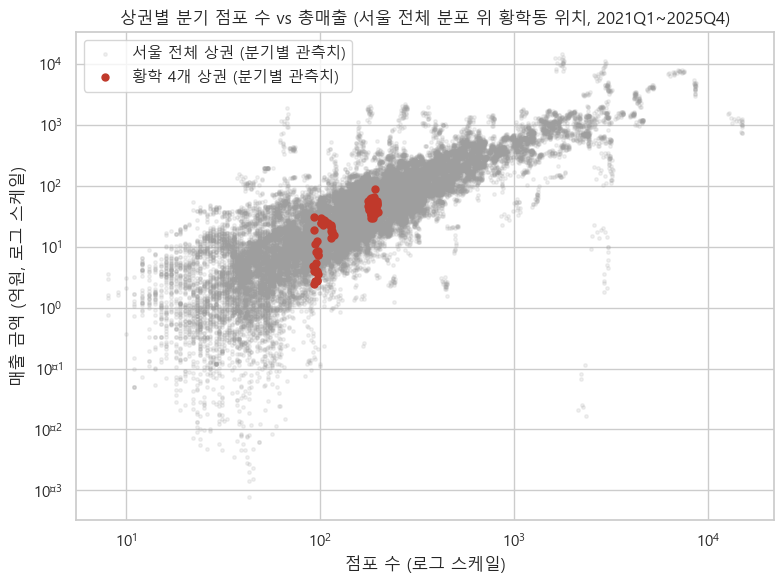

In [38]:
store_level_df = area_quarter_summary.dropna(subset=["총매출금액", "점포수"]).copy()
store_level_df["황학여부"] = store_level_df["상권_코드"].isin(HWANGHAK_CODES)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(store_level_df.loc[~store_level_df["황학여부"], "점포수"],
           store_level_df.loc[~store_level_df["황학여부"], "총매출금액"] / 1e8,
           s=6, alpha=0.15, color=SEOUL_COLOR, label="서울 전체 상권 (분기별 관측치)")
ax.scatter(store_level_df.loc[store_level_df["황학여부"], "점포수"],
           store_level_df.loc[store_level_df["황학여부"], "총매출금액"] / 1e8,
           s=25, color=HWANGHAK_COLOR, label="황학 4개 상권 (분기별 관측치)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("점포 수 (로그 스케일)")
ax.set_ylabel("매출 금액 (억원, 로그 스케일)")
ax.set_title("상권별 분기 점포 수 vs 총매출 (서울 전체 분포 위 황학동 위치, 2021Q1~2025Q4)")
ax.legend()
plt.tight_layout()
plt.show()

**해석:** 점포 수 대비 매출도 로그-로그 상에서 황학 4개 상권이 서울 전체 분포의 중간 지점 부근에 위치하며,
뚜렷한 이상치로 보이지는 않는다.

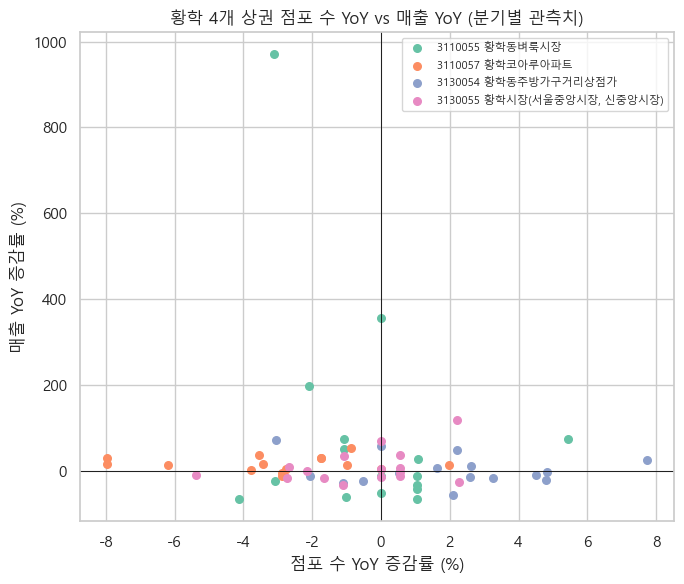

In [39]:
hwanghak_change["폐업점포수_YoY(%)"] = hwanghak_change.groupby("상권_코드")["폐업점포수"].pct_change(periods=4) * 100
hwanghak_change["점포수_YoY(%)"] = hwanghak_change.groupby("상권_코드")["점포수"].pct_change(periods=4) * 100
hwanghak_change_valid2 = hwanghak_change.dropna(subset=["매출_YoY(%)", "점포수_YoY(%)"])

fig, ax = plt.subplots(figsize=(7, 6))
for i, code_ in enumerate(HWANGHAK_CODES):
    sub = hwanghak_change_valid2[hwanghak_change_valid2["상권_코드"] == code_]
    ax.scatter(sub["점포수_YoY(%)"], sub["매출_YoY(%)"], color=AREA_PALETTE[i],
               label=f"{code_} {area_names_hwanghak[code_]}", s=30)
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("점포 수 YoY 증감률 (%)")
ax.set_ylabel("매출 YoY 증감률 (%)")
ax.set_title("황학 4개 상권 점포 수 YoY vs 매출 YoY (분기별 관측치)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**해석:** 점포 수 YoY와 매출 YoY의 관계에서도 방향이 엇갈리는 사례가 확인된다. 연간 비교 기준으로
황학코아루아파트는 점포 수가 -11.5% 줄었는데 매출은 +63.9% 늘었고, 반대로 황학동주방가구거리상점가는
점포 수가 +7.5% 늘었는데 매출은 -15.1% 줄었다. 즉 점포 수와 매출의 증감 방향이 항상 함께 움직이지는
않으며, "점포 수가 유지/증가하면 매출도 그렇다"는 가정은 이 데이터에서 일관되게 성립하지 않는다.

## 18. 황학 4개 상권 비교

지금까지의 핵심 지표를 상권별로 정리하여 4개 상권이 서로 얼마나 다른지 확인한다 (아직 종합 점수는
만들지 않는다). "최근"은 2025년(4개 분기 합계/평균), "초기"는 2021년(4개 분기 합계/평균) 기준이다.

In [40]:
summary_rows = []
for code_ in HWANGHAK_CODES:
    name = area_names_hwanghak[code_]

    s_2021 = hwanghak_sales[(hwanghak_sales["상권_코드"] == code_) & (hwanghak_sales["기준_년분기_코드"].between(20211, 20214))]
    s_2025 = hwanghak_sales[(hwanghak_sales["상권_코드"] == code_) & (hwanghak_sales["기준_년분기_코드"].between(20251, 20254))]
    st_2025 = hwanghak_stores[(hwanghak_stores["상권_코드"] == code_) & (hwanghak_stores["기준_년분기_코드"].between(20251, 20254))]
    p_2025 = hwanghak_population[(hwanghak_population["상권_코드"] == code_) & (hwanghak_population["기준_년분기_코드"].between(20251, 20254))]

    top_cat_2025 = s_2025.groupby("서비스_업종_코드_명")["당월_매출_금액"].sum().sort_values(ascending=False)
    top_time_2025 = s_2025[TIME_AMOUNT_COLS].sum().sort_values(ascending=False)
    top_age_2025 = s_2025[AGE_AMOUNT_COLS].sum().sort_values(ascending=False)
    weekday_2025 = s_2025["주중_매출_금액"].sum()
    weekend_2025 = s_2025["주말_매출_금액"].sum()

    summary_rows.append({
        "상권_코드": code_,
        "상권명": name,
        "2021_매출(억원)": s_2021["당월_매출_금액"].sum() / 1e8,
        "2025_매출(억원)": s_2025["당월_매출_금액"].sum() / 1e8,
        "2025_점포수(연평균)": st_2025.groupby("기준_년분기_코드")["점포_수"].sum().mean(),
        "2025_개업점포수(연합계)": st_2025["개업_점포_수"].sum(),
        "2025_폐업점포수(연합계)": st_2025["폐업_점포_수"].sum(),
        "2025_유동인구(분기평균,만명)": p_2025["총_유동인구_수"].mean() / 1e4,
        "2025_주말비중(%)": weekend_2025 / (weekday_2025 + weekend_2025) * 100,
        "2025_최다시간대": top_time_2025.index[0].replace("시간대_", "").replace("_매출_금액", ""),
        "2025_최다연령대": top_age_2025.index[0].replace("연령대_", "").replace("_매출_금액", "대").replace("60_이상대", "60대 이상"),
        "2025_1위업종": top_cat_2025.index[0] if len(top_cat_2025) > 0 else None,
    })

hwanghak_area_summary = pd.DataFrame(summary_rows).set_index(["상권_코드", "상권명"])
display(hwanghak_area_summary.round(2))

,,2021_매출(억원),2025_매출(억원),2025_점포수(연평균),2025_개업점포수(연합계),2025_폐업점포수(연합계),"2025_유동인구(분기평균,만명)",2025_주말비중(%),2025_최다시간대,2025_최다연령대,2025_1위업종
상권_코드,상권명,,,,,,,,,,
3110055,황학동벼룩시장,25.62,55.77,93.0,4,5,42.28,68.43,17~21,30대,전자상거래업
3110057,황학코아루아파트,63.81,104.59,102.0,8,9,87.94,27.09,17~21,30대,한식음식점
3130054,황학동주방가구거리상점가,207.15,175.79,195.5,17,14,125.80,16.40,14~17,60대 이상,가구
3130055,"황학시장(서울중앙시장, 신중앙시장)",148.07,168.99,179.0,17,21,95.56,24.73,17~21,60대 이상,한식음식점


**해석:** 위 표에서 확인되듯 매출 "규모"가 가장 큰 상권(황학동주방가구거리상점가 2025년 175.8억원,
황학시장 169.0억원)과 매출 "성장률"이 가장 높은 상권(황학동벼룩시장 +117.7%, 황학코아루아파트 +63.9%)이
서로 다르다. 특정 한 상권이 황학동 4개 상권 합계 결과를 일방적으로 주도한다기보다, 규모가 큰 전통 상권(주방가구
거리상점가)의 정체·감소와 상대적으로 작은 상권들(벼룩시장·코아루아파트)의 빠른 성장이 함께 나타나며
황학동 합계 지표는 이 두 흐름이 섞인 결과에 가깝다. 최다 판매 업종도 상권별로 다르다(벼룩시장은
전자상거래업, 코아루아파트·황학시장은 한식음식점, 주방가구거리상점가는 가구).

## 19. 서울 전체 내 황학동 상대적 위치 탐색

최근 분기(2025Q4)를 기준으로 서울 전체 상권의 매출/점포수/유동인구 분포 안에서 황학 4개 상권이
어디에 위치하는지 확인한다. 절대적인 우열이 아니라 **분포 내 상대적 위치(percentile)** 를 참고용으로만
계산하며, 이 값을 아직 쇠퇴지수 등으로 사용하지 않는다.

[2025Q4 기준 황학 4개 상권의 서울 전체 분포 내 percentile]
  총매출 - 3110055 황학동벼룩시장: 값=19.0, 서울 상권 중 하위 37.6% 지점
  점포 수 - 3110055 황학동벼룩시장: 값=93.0, 서울 상권 중 하위 35.6% 지점
  유동인구 - 3110055 황학동벼룩시장: 값=34.1, 서울 상권 중 하위 35.9% 지점
  총매출 - 3110057 황학코아루아파트: 값=29.8, 서울 상권 중 하위 47.3% 지점
  점포 수 - 3110057 황학코아루아파트: 값=101.0, 서울 상권 중 하위 38.2% 지점
  유동인구 - 3110057 황학코아루아파트: 값=85.7, 서울 상권 중 하위 67.0% 지점
  총매출 - 3130054 황학동주방가구거리상점가: 값=37.1, 서울 상권 중 하위 51.6% 지점
  점포 수 - 3130054 황학동주방가구거리상점가: 값=199.0, 서울 상권 중 하위 64.7% 지점
  유동인구 - 3130054 황학동주방가구거리상점가: 값=110.8, 서울 상권 중 하위 75.2% 지점
  총매출 - 3130055 황학시장(서울중앙시장, 신중앙시장): 값=39.7, 서울 상권 중 하위 53.5% 지점
  점포 수 - 3130055 황학시장(서울중앙시장, 신중앙시장): 값=178.0, 서울 상권 중 하위 61.0% 지점
  유동인구 - 3130055 황학시장(서울중앙시장, 신중앙시장): 값=86.7, 서울 상권 중 하위 67.2% 지점


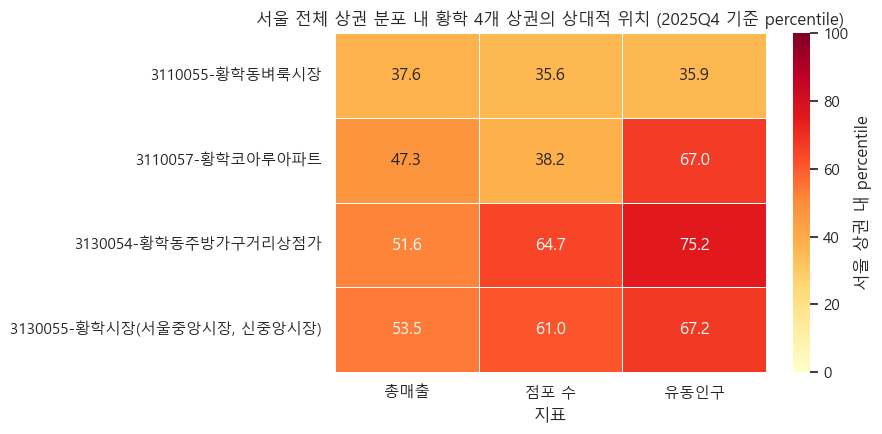

In [41]:
LATEST_QUARTER = QUARTER_ORDER[-1]
latest_summary = area_quarter_summary[area_quarter_summary["기준_년분기_코드"] == LATEST_QUARTER].copy()
latest_summary["황학여부"] = latest_summary["상권_코드"].isin(HWANGHAK_CODES)

metrics = [("총매출금액", "총매출", 1e8), ("점포수", "점포 수", 1), ("총_유동인구_수", "유동인구", 1e4)]

print(f"[{QUARTER_LABEL_MAP[LATEST_QUARTER]} 기준 황학 4개 상권의 서울 전체 분포 내 percentile]")
percentile_rows = []
for code_ in HWANGHAK_CODES:
    row = {"상권_코드": code_, "상권_코드_명": area_names_hwanghak[code_]}
    for col, label, unit in metrics:
        valid = latest_summary.dropna(subset=[col])
        area_row = valid[valid["상권_코드"] == code_]
        if len(area_row) == 0:
            print(f"  {label} - {code_} {area_names_hwanghak[code_]}: 해당 분기 값 없음")
            row[label] = np.nan
            continue
        val = area_row[col].iloc[0]
        pct = (valid[col] < val).mean() * 100
        print(f"  {label} - {code_} {area_names_hwanghak[code_]}: 값={val/unit:.1f}, 서울 상권 중 하위 {pct:.1f}% 지점")
        row[label] = pct
    percentile_rows.append(row)

percentile_df = pd.DataFrame(percentile_rows).set_index(["상권_코드", "상권_코드_명"])

# 일부 극단값 때문에 boxplot에서는 4개 상권의 위치가 하단에 몰려 잘 드러나지 않으므로,
# 이미 계산한 percentile(0~100)을 heatmap으로 시각화해 서울 전체 분포 내 상대적 위치를 직관적으로 비교한다.
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(percentile_df, annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=100,
            cbar_kws={"label": "서울 상권 내 percentile"},
            linewidths=0.5, ax=ax)
ax.set_title(f"서울 전체 상권 분포 내 황학 4개 상권의 상대적 위치 ({QUARTER_LABEL_MAP[LATEST_QUARTER]} 기준 percentile)")
ax.set_xlabel("지표")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**해석:** 위 percentile heatmap에서 볼 수 있듯이, 2025Q4 기준으로 황학 4개 상권은 매출 기준 서울 전체 상권 중 하위 37.6~53.5%(중간 이하~중간),
점포 수 기준 35.6~64.7%, 유동인구 기준 35.9~75.2% 구간에 위치한다. 서울 전체에서 극단적으로 크거나
작은 상권은 아니고 대체로 중위권에 속한다. 다만 황학동주방가구거리상점가는 유동인구 percentile(75.2%)이
매출 percentile(51.6%)보다 상당히 높게 나타나, 유동인구 규모에 비해 매출로 이어지는 정도가 상대적으로
낮은 상권일 가능성을 시사한다(이 지점은 추가 확인이 필요한 신호로 아래 요약에 남겨둔다).

## 20. 초기 시점 vs 최근 시점 비교

**비교 방식: 2021년 vs 2025년 (분기 4개 합계/평균)**. 단일 분기(2021Q1 vs 2025Q4)만 비교하면 그
분기에 국한된 우연한 변동(계절성, 일시적 이벤트)이 전체 인상을 좌우할 위험이 있다. 이 노트북에서는
매출·매출건수·개업/폐업 점포 수처럼 분기 동안 발생한 흐름(flow)을 누적하는 지표는 **4개 분기 합계**로,
점포 수처럼 특정 시점의 재고성(stock) 지표는 **연중 4개 분기 평균**으로 비교하여 분기별 변동의 영향을 줄인다.

**생활인구(`총_유동인구_수`)에 대한 별도 주의**: 매출과 달리 생활인구는 4개 분기 값을 그대로 합산하는 것이
원본 데이터의 공식 집계 기준상 타당한지 이 노트북만으로는 확인할 수 없다(연간 합산 해석은 원본 데이터의
집계 기준 확인이 필요하다). 따라서 생활인구는 합계 대신 **4개 분기 평균**을 대표값으로 사용한다. 다만 2021년과
2025년 모두 동일하게 4개 분기이므로, 합계 기준과 평균 기준의 증감률(%) 자체는 수학적으로 동일하다 — 이는
대표값 표기 방식을 보완한 것이며 기존 증감률 결과를 바꾸지 않는다.

In [42]:
def year_flow_sum(df, cols, year_quarters):
    return df[df["기준_년분기_코드"].isin(year_quarters)][cols].sum()


Q_2021 = [20211, 20212, 20213, 20214]
Q_2025 = [20251, 20252, 20253, 20254]

hw_sales_2021 = hwanghak_sales[hwanghak_sales["기준_년분기_코드"].isin(Q_2021)]
hw_sales_2025 = hwanghak_sales[hwanghak_sales["기준_년분기_코드"].isin(Q_2025)]
hw_stores_2021 = hwanghak_stores[hwanghak_stores["기준_년분기_코드"].isin(Q_2021)]
hw_stores_2025 = hwanghak_stores[hwanghak_stores["기준_년분기_코드"].isin(Q_2025)]
hw_pop_2021 = hwanghak_population[hwanghak_population["기준_년분기_코드"].isin(Q_2021)]
hw_pop_2025 = hwanghak_population[hwanghak_population["기준_년분기_코드"].isin(Q_2025)]

overview_2021_vs_2025 = pd.DataFrame({
    "2021": {
        "총매출금액(억원)": hw_sales_2021["당월_매출_금액"].sum() / 1e8,
        "총매출건수(만건)": hw_sales_2021["당월_매출_건수"].sum() / 1e4,
        "점포수(연평균)": hw_stores_2021.groupby("기준_년분기_코드")["점포_수"].sum().mean(),
        "개업점포수(연합계)": hw_stores_2021["개업_점포_수"].sum(),
        "폐업점포수(연합계)": hw_stores_2021["폐업_점포_수"].sum(),
        "프랜차이즈점포수(연평균)": hw_stores_2021.groupby("기준_년분기_코드")["프랜차이즈_점포_수"].sum().mean(),
        "총유동인구(4개분기 평균,만명)": hw_pop_2021.groupby("기준_년분기_코드")["총_유동인구_수"].sum().mean() / 1e4,
        "주말매출비중(%)": hw_sales_2021["주말_매출_금액"].sum() / (hw_sales_2021["주중_매출_금액"].sum() + hw_sales_2021["주말_매출_금액"].sum()) * 100,
    },
    "2025": {
        "총매출금액(억원)": hw_sales_2025["당월_매출_금액"].sum() / 1e8,
        "총매출건수(만건)": hw_sales_2025["당월_매출_건수"].sum() / 1e4,
        "점포수(연평균)": hw_stores_2025.groupby("기준_년분기_코드")["점포_수"].sum().mean(),
        "개업점포수(연합계)": hw_stores_2025["개업_점포_수"].sum(),
        "폐업점포수(연합계)": hw_stores_2025["폐업_점포_수"].sum(),
        "프랜차이즈점포수(연평균)": hw_stores_2025.groupby("기준_년분기_코드")["프랜차이즈_점포_수"].sum().mean(),
        "총유동인구(4개분기 평균,만명)": hw_pop_2025.groupby("기준_년분기_코드")["총_유동인구_수"].sum().mean() / 1e4,
        "주말매출비중(%)": hw_sales_2025["주말_매출_금액"].sum() / (hw_sales_2025["주중_매출_금액"].sum() + hw_sales_2025["주말_매출_금액"].sum()) * 100,
    },
})
overview_2021_vs_2025["증감"] = overview_2021_vs_2025["2025"] - overview_2021_vs_2025["2021"]
overview_2021_vs_2025["증감률(%)"] = overview_2021_vs_2025["증감"] / overview_2021_vs_2025["2021"] * 100
display(overview_2021_vs_2025.round(2))

,2021,2025,증감,증감률(%)
총매출금액(억원),444.65,505.15,60.49,13.60
총매출건수(만건),104.37,129.10,24.73,23.69
점포수(연평균),575.00,569.50,-5.50,-0.96
개업점포수(연합계),47.00,46.00,-1.00,-2.13
폐업점포수(연합계),45.00,49.00,4.00,8.89
프랜차이즈점포수(연평균),29.25,35.50,6.25,21.37
"총유동인구(4개분기 평균,만명)",324.34,351.58,27.24,8.40
주말매출비중(%),18.96,27.14,8.18,43.16


**해석:** 2021년 대비 2025년 황학동 4개 상권 합계는 매출금액(+13.6%), 매출건수(+23.7%), 유동인구
(+8.4%, 4개 분기 평균 기준), 프랜차이즈 점포 수(+21.4%) 모두 증가했다. 반면 점포 수는 -1.0%로 거의 변화가 없고, 개업
점포 수는 -2.1%로 소폭 줄고 폐업 점포 수는 +8.9%로 늘어 순증가 폭이 줄어드는 방향이다. 주말 매출 비중은
+8.18%p(상대 +43.2%)로 가장 큰 상대 변화폭을 보인다. 종합하면 총량 지표는 대체로 성장했지만, 점포
증감의 질(개업 대비 폐업 비중)과 소비 시간 구조는 함께 변화하고 있다.

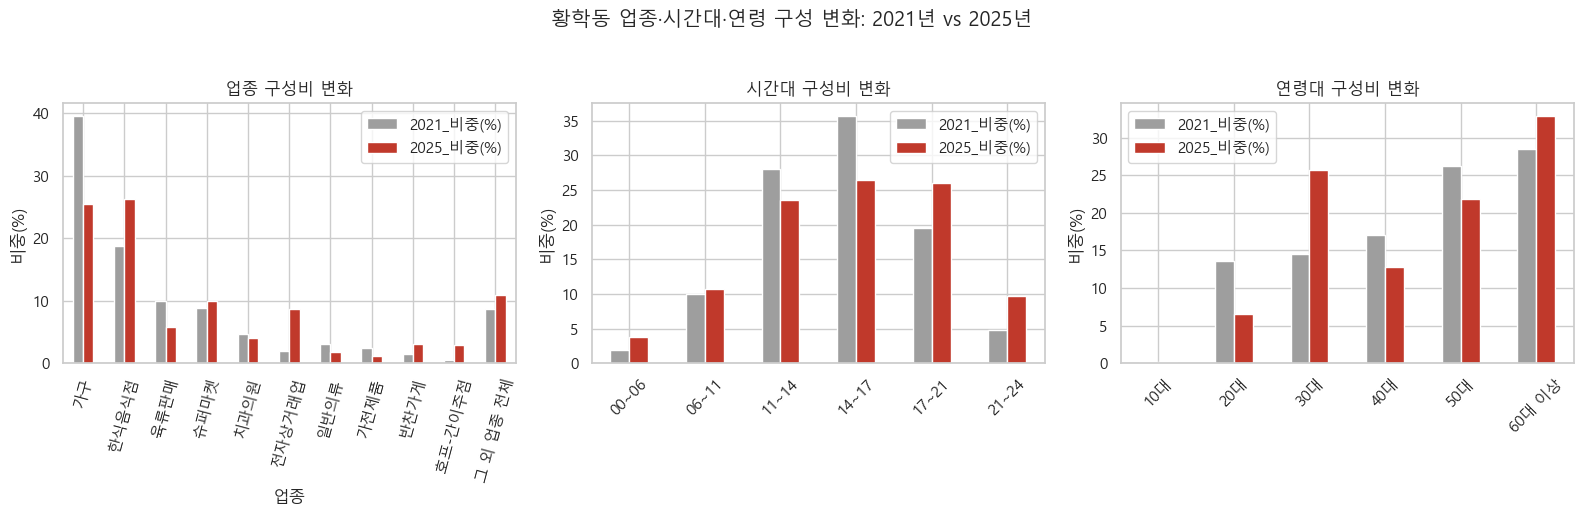

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 업종 구성 (TOP 10 + 그 외, 이미 계산된 comp_df 재사용)
comp_plot_df = comp_df.set_index("업종")[["2021_비중(%)", "2025_비중(%)"]]
comp_plot_df.plot(kind="bar", ax=axes[0], color=[SEOUL_COLOR, HWANGHAK_COLOR])
axes[0].set_title("업종 구성비 변화")
axes[0].set_ylabel("비중(%)")
axes[0].tick_params(axis="x", rotation=75)

# 시간대 구성
time_2021 = hw_sales_2021[TIME_AMOUNT_COLS].sum()
time_2025 = hw_sales_2025[TIME_AMOUNT_COLS].sum()
time_compare = pd.DataFrame({
    "2021_비중(%)": time_2021 / time_2021.sum() * 100,
    "2025_비중(%)": time_2025 / time_2025.sum() * 100,
})
time_compare.index = TIME_LABELS
time_compare.plot(kind="bar", ax=axes[1], color=[SEOUL_COLOR, HWANGHAK_COLOR])
axes[1].set_title("시간대 구성비 변화")
axes[1].set_ylabel("비중(%)")
axes[1].tick_params(axis="x", rotation=45)

# 연령 구성 (이미 계산된 age_compare 재사용)
age_compare.plot(kind="bar", ax=axes[2], color=[SEOUL_COLOR, HWANGHAK_COLOR])
axes[2].set_title("연령대 구성비 변화")
axes[2].set_ylabel("비중(%)")
axes[2].tick_params(axis="x", rotation=45)

fig.suptitle("황학동 업종·시간대·연령 구성 변화: 2021년 vs 2025년", y=1.03)
plt.tight_layout()
plt.show()

**해석:** 업종·시간대·연령 세 구성 모두에서 뚜렷한 변화가 확인된다. 업종은 가구 중심에서 한식음식점·
전자상거래업 중심으로, 시간대는 낮(11~17시) 중심에서 저녁·야간(17~24시) 중심으로, 연령은 20대 감소와
30대·60대 이상 증가라는 다소 엇갈리는 방향으로 움직였다. 세 축 모두 "쇠퇴"라는 하나의 방향으로만 설명되지
않으며, 오히려 소비 구조 자체가 재편되고 있다는 인상에 더 가깝다.

## 21. 핵심 EDA 결과 요약

지금까지의 실행 결과를 세 가지 관점으로 정리한다.

### A. 쇠퇴 가능성을 시사하는 신호

- 2021년 기준 황학동 4개 상권 매출의 약 46.6%를 차지하던 가장 큰 상권인 **황학동주방가구거리상점가(3130054)**의
  매출이 2021년 207.1억원 -> 2025년 175.8억원으로 **-15.1% 감소**했다. 같은 기간 이 상권의 유동인구는
  +19.8%, 점포 수는 +7.5% 늘었음에도 매출만 줄었다.
- 황학동 4개 상권 합계 기준 **폐업 점포 수가 연 45건(2021)-> 49건(2025)으로 늘고, 개업 점포 수는 47건
  -> 46건으로 소폭 줄어** 순증가 폭이 축소되는 방향이다.
- 전체 기간 누적 매출 1위였던 **가구 업종의 비중이 39.6%(2021) -> 25.5%(2025)로 -14.1%p 축소**되고
  절대 매출도 -26.9% 감소해, 상권의 전통적 근간 업종이 약화되는 모습이 뚜렷하다.
- 매출 연령 구성에서 **20대 비중이 13.7%(2021) -> 6.5%(2025)로 거의 절반 수준으로 감소**했다.

### B. 구조 변화 또는 회복 가능성을 시사하는 신호

- 황학동 4개 상권 합계 매출은 2021년 444.7억원 -> 2025년 505.2억원으로 **+13.6% 증가**했고, 매출
  건수(+23.7%)와 유동인구(+8.4%)도 함께 늘었다 — 단순 총량 기준으로는 쇠퇴가 아니라 성장이다.
- **황학동벼룩시장(+117.7%)**과 **황학코아루아파트(+63.9%)**의 매출이 크게 늘며 새로운 성장축으로
  부상했다. 벼룩시장은 2025년 기준 최다 판매 업종이 **전자상거래업**으로 바뀌었고, 주말 매출 비중도
  32.8% -> 68.4%로 완전히 주말 중심 상권으로 전환되었다.
- 업종 구성에서 **한식음식점(+58.8%, 비중 +7.5%p), 전자상거래업(+393%, +6.7%p), 호프-간이주점(+501%),
  커피-음료(2021년에는 거의 없던 업종이 2025년 TOP10 진입)** 등 새로운 소비 업종이 뚜렷하게 성장했다.
- 소비 시간 구조가 **낮(11~17시) 중심(63.8%->50.0%)에서 저녁·야간(17~24시) 중심(24.3%->35.6%)으로
  이동**했고, **주말 매출 비중도 19.0%->27.1%(상대 +43%)로 확대**되었다. 같은 기간 **서울 전체 합산
  매출 기준 주말 비중은 24.5%->24.5%로 거의 변화가 없었고**, 서울 개별 상권 분포 기준(median)으로 봐도
  24.9%->24.8%로 사실상 변화가 없어, 이는 서울 전체의 공통 추세가 아니라 황학동에 특히 뚜렷한 변화다.
  같은 기간 황학동벼룩시장은 서울 개별 상권 주말비중 분포에서 하위 89.0%(2021) -> 하위 99.9%(2025)
  지점으로 올라서, 서울 상권 중 거의 최상위 수준의 주말 중심 상권이 되었다.
- **프랜차이즈 점포 수가 연평균 29.25개(2021) -> 35.5개(2025)로 +21.4% 증가**했고, 매출 연령 구성에서
  **30대 비중이 14.5%(2021) -> 25.8%(2025)로 크게 증가**했다.

### C. 추가 확인이 필요한 신호

- **황학동주방가구거리상점가**는 유동인구(+19.8%)·점포 수(+7.5%)가 모두 늘었는데 매출만 줄어드는
  (-15.1%) 조합을 보인다. 반대로 **황학코아루아파트**는 점포 수가 -11.5% 줄었는데 매출은 +63.9% 늘어
  정반대 조합을 보인다. 점포 수·유동인구·매출이 함께 움직이지 않는 상권이 실제로 존재한다.
- 매출 연령 구성(20대 감소·30대 증가·60대 이상 증가)과 생활인구 연령 구성(60대 이상 비중은 오히려
  감소, 10·40대는 소폭 증가)이 서로 다른 방향으로 움직인다 — **방문객 연령 구성 변화와 소비 연령 구성
  변화가 일치하지 않는다.**
- 서울 전체 상권-분기 관측치 기준 유동인구-매출 **상관계수는 0.313**으로 약한 양의 관계에 그쳐, 유동인구
  만으로 매출 수준을 설명하기 어렵다.
- 황학 4개 상권은 매출·유동인구·시간대·연령 구성 모든 지표에서 서로 다른 궤적을 보이며, 황학동 합계
  지표(+13.6% 매출 성장 등)는 이 네 상권의 서로 다른(때로는 반대되는) 변화가 상쇄되어 나타난 결과에
  가깝다.

## 22. EDA 결론

> 이번 EDA에서는 황학동 4개 상권의 매출·매출건수·유동인구가 2021년 대비 2025년 전반적으로 증가했지만,
> 그 이면에서는 상권별로 — 특히 전통적으로 가장 큰 비중을 차지했던 황학동주방가구거리상점가에서 —
> 매출이 감소하는 등 상반된 흐름이 동시에 관찰되었다. 업종 구성은 가구 중심에서 음식점·전자상거래·주류
> 등으로, 소비 시간은 낮 중심에서 저녁·야간·주말 중심으로 이동하는 뚜렷한 구조 변화도 함께 확인되었다.
> 따라서 황학동의 변화를 단순한 총매출 증감만으로 평가하기보다는, 상권별·업종별·시간대별·연령별 지표를
> 함께 결합해 쇠퇴와 회복(혹은 구조 전환) 신호를 구분해서 정의할 필요가 있다.

이 노트북은 "황학동은 쇠퇴했다" 또는 "황학동은 회복 중이다"라는 확정적 결론을 내리지 않는다. 위 21절의
A/B/C 신호는 어디까지나 다음 단계에서 정량적으로 검증해야 할 가설 수준으로 남겨둔다. 특히 (1) 주방가구
거리상점가처럼 유동인구·점포 수는 늘어도 매출이 줄어드는 상권이 실제로 존재한다는 점, (2) 방문객 연령
구성과 소비 연령 구성이 어긋난다는 점은 인과관계를 성급히 결론짓지 않고 후속 분석에서 반드시 재검증해야
한다.

## 23. 다음 단계 제안

다음 단계 노트북으로는 `04_feature_engineering.ipynb`를 우선 제안한다. 이번 EDA에서 확인된 신호(예:
주방가구거리상점가의 유동인구·매출 디커플링, 업종/시간대/연령 구조 변화)를 곧바로 하나의 지수로 요약하기보다,
먼저 안정적인 파생 변수(성장률, 비중, index 등)를 상권·업종 단위로 체계적으로 만드는 단계가 필요하기
때문이다. 이후 이 feature들을 바탕으로 쇠퇴·회복 신호를 정의하는 노트북을 별도로 이어간다면
`05_commercial_signal.ipynb`와 같은 이름을 붙일 수 있다.

다음 단계에서 다룰 수 있는 항목(이번 노트북에서는 구현하지 않음):

- 상권별·업종별 매출 성장률(YoY, 초기 대비 최근) 및 변동성(표준편차 등) 지표화
- 점포 순증감(개업-폐업), 폐업 점포 수 추세, 프랜차이즈화 비율 등 점포 관련 지표화
- 유동인구 성장률과 매출 성장률의 괴리(디커플링) 지표 — 특히 주방가구거리상점가와 같은 사례를 정량적으로
  포착하는 지표
- 업종 구성 변화 지표화(예: 가구 의존도, 신규 업종 비중)
- 시간대 구성 지표(주말 비중, 야간 비중 등)의 정량화 및 서울 전체 대비 상대 지표화
- 연령 구성 지표(20~30대 비중 등)를 매출/생활인구 각각에 대해 정량화하고 두 지표 간 괴리를 확인하는 지표
- 위 지표들을 상권코드 단위로 집계해 서울 전체 상권과 비교할 수 있는 feature 테이블 구성(향후 유사 상권
  탐색·군집분석의 입력으로 사용)

이번 `03_eda.ipynb`에서는 위 항목의 구현을 하지 않는다.